In [36]:
library(ggplot2)
library(scattermore)
# integration data
# 

# https=//satijalab.org/seurat/articles/seurat5_integration

.libPaths(c('/sc/arion/projects/CommonMind/liting/conda/envs/Py39_R43_Ju10/lib/R/library',.libPaths()))
library(RColorBrewer)
library(scales)
library(schard)
library(SeuratWrappers)
library(ggVennDiagram)
library(Seurat)
library(slingshot)
library(ComplexHeatmap)
library(circlize)
library(dplyr)
library(zellkonverter)
# functions 
# intergrate NN and ENT data, and perform trajectory inference

library(Seurat)
library(dplyr)
library(Seurat)
library(patchwork)

library(BiocManager)

library(scuttle)
library(reticulate)
library(Seurat)
library(uwot)
library(stringr)


library(ggplot2)
library(ggplot2)
library(scattermore)

# https=//satijalab.org/seurat/articles/seurat5_integration
# intergrate NN and ENT data, and perform trajectory inference
options(repr.plot.width = 7, repr.plot.height = 5)

In [37]:
ent_N <- readRDS('/sc/arion/projects/CommonMind/roussp01a/ENT/snRNAseq/qc_scanpy/ent_nn_merge_cca.rds')
ent_N[["RNA"]] <- as(object = ent_N[["RNA"]], Class = "Assay5")
ent_N <- JoinLayers(ent_N)

In [38]:
lister <- readH5AD('/sc/arion/projects/CommonMind/aging/hui/files/lister_processed.h5ad', use_hdf5=TRUE, verbose=F)
lister@colData$stage_celltype <- paste(lister@colData$stage_id,lister@colData$major_clust)

Warning message:
“The names of these selected uns$major_clust_colors_dict items have been
modified to match R conventions: 'L2-3_CUX2' -> 'L2.3_CUX2', 'L5-6_THEMIS' ->
'L5.6_THEMIS', 'L5-6_TLE4' -> 'L5.6_TLE4', and 'Poor-Quality' -> 'Poor.Quality'”
Warning message:
“The names of these selected uns items have been modified to match R
conventions: 'Astro_GFAP_dev-traj_colors' -> 'Astro_GFAP_dev.traj_colors',
'Astro_SLC1A2_dev-traj_colors' -> 'Astro_SLC1A2_dev.traj_colors',
'CCK_RELN_dev-traj_colors' -> 'CCK_RELN_dev.traj_colors',
'CCK_SORCS1_dev-traj_colors' -> 'CCK_SORCS1_dev.traj_colors',
'CCK_SYT6_dev-traj_colors' -> 'CCK_SYT6_dev.traj_colors',
'ID2_CSMD1_dev-traj_colors' -> 'ID2_CSMD1_dev.traj_colors',
'L2_CUX2_LAMP5_dev-traj_colors' -> 'L2_CUX2_LAMP5_dev.traj_colors',
'L3_CUX2_PRSS12_dev-traj_colors' -> 'L3_CUX2_PRSS12_dev.traj_colors',
'L4_RORB_LRRK1_dev-traj_colors' -> 'L4_RORB_LRRK1_dev.traj_colors',
'L4_RORB_MET_dev-traj_colors' -> 'L4_RORB_MET_dev.traj_colors',
'L4_RORB_MME_dev

In [39]:
#lister <- readH5AD('/sc/arion/projects/CommonMind/aging/hui/files/lister_processed.h5ad', use_hdf5=TRUE, verbose=F)
lister_hvg <- read.csv('lister_hvg.csv')


#meta.data <- subset(lister@colData, cell_type %in% c("PN") )
meta.data <- subset(lister@colData , !cell_type %in%c('Poor-Quality'))
set.seed(123)

meta.data$name <- rownames(meta.data)
#meta.data <- meta.data[sample(1:nrow(meta.data),50000),]
ExN_data <- lister[,rownames(meta.data)]

# meta.data <- as.data.frame(meta.data)%>%group_by(stage_id)%>%sample_n(3000)
# ExN_data <- lister[,meta.data$name]


ExN_data <- CreateSeuratObject(counts = as(ExN_data@assays@data$X,"sparseMatrix"), meta.data = meta.data)
ExN_data$major_clust <- meta.data$major_clust
ExN_data$stage_id <- meta.data$stage_id
ExN_data$cluster_stage <- paste( ExN_data$stage_id, ExN_data$major_clust)


library(edgeR)
load('/sc/arion/projects/roussp01a/liting/Olf/data/DEG_trend_Olf_k7_graph.RData')

# pseudo_bulk
pseudo_cluster <- as.data.frame(AggregateExpression(ExN_data, assays = "RNA", return.seurat = F, group.by = c('major_clust', "cluster_stage",'stage_id')[1])$RNA)

# pseudo_bulk ENT
ent_N$cca_N_types_stage_dataset <- paste(ent_N$cca_N_types_stage,ent_N$dataset)
pseudo_cluster_ENT <- as.data.frame(AggregateExpression(ent_N, assays = "RNA", return.seurat = F, group.by = c("cca_N_types_stage"))$RNA)#'dataset',

pseudo_cluster <- log(cpm(pseudo_cluster+1))
pseudo_cluster_ENT <- log(cpm(pseudo_cluster_ENT+1))
colnames(pseudo_cluster_ENT) <- gsub('-','_',colnames(pseudo_cluster_ENT))
colnames(pseudo_cluster) <- gsub('-','_',colnames(pseudo_cluster))

lister_hvgs <- lister_hvg$X[lister_hvg$highly_variable=='True']


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“[[<- defined for objects of type "S4" only for subclasses of environment”


Finding variable features for layer counts

Finding variable features for layer counts



[1] 482


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”
Finding variable features for layer counts

Finding variable features for layer counts



[1] 482


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”
Finding variable features for layer counts

Finding variable features for layer counts



...

Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”
Finding variable features for layer counts

Finding variable features for layer counts



[1] 3743


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”
Finding variable features for layer counts

Finding variable features for layer counts



[1] 3743


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


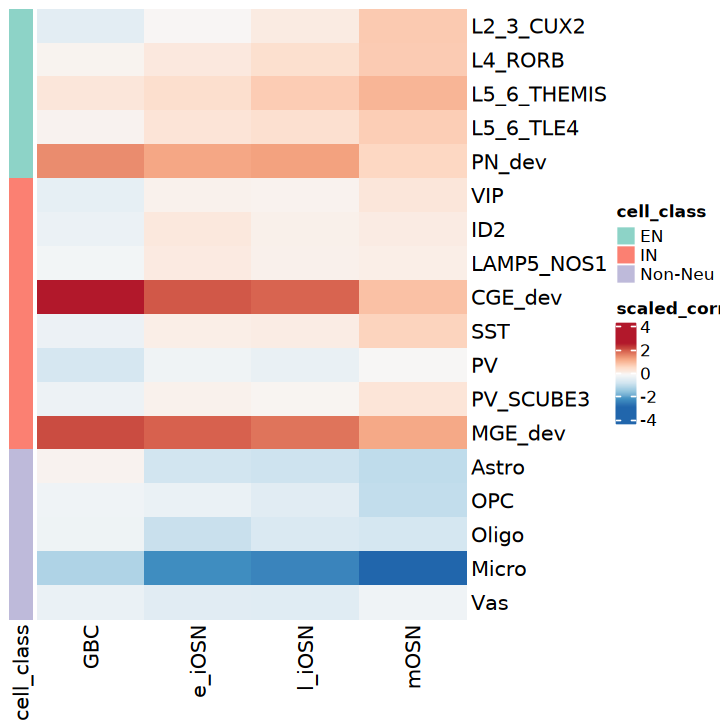

In [40]:
for (nf in c(2000,3000,4000,5000,6000,7000,10000)){
    for (cor_md in c('spearman','kendall','pearson')){
        for (hvg in c('HVG','HVG_ent','HVG_en')){
            
        ExN_data <- FindVariableFeatures(ExN_data, nfeatures = nf)
        ent_N <- FindVariableFeatures(ent_N, nfeatures = nf) # for identify DEGs using slingshot
        print(length(intersect( VariableFeatures(ExN_data), VariableFeatures(ent_N))))
        corr_he <- c()
        for (ct1 in colnames(pseudo_cluster_ENT)){
            for (ct2 in colnames(pseudo_cluster)){

                if(hvg=='HVG'){ intersect_genes <- intersect(VariableFeatures(ExN_data),VariableFeatures(ent_N))}
                if(hvg=='HVG_ent'){ intersect_genes <- intersect( rownames(ExN_data), VariableFeatures(ent_N))}
                if(hvg=='HVG_en'){ intersect_genes <- intersect( VariableFeatures(ExN_data), rownames(ent_N))}

                pseudo_clusterx <- pseudo_cluster[intersect_genes,ct2]
                pseudo_cluster_ENTx <- pseudo_cluster_ENT[intersect_genes,ct1]
                x= cor(pseudo_clusterx,pseudo_cluster_ENTx,method = cor_md)
                names(x) <- paste(ct1,ct2)
                corr_he <- c(corr_he,x)
            } 
        }

        corr_he <- as.data.frame(corr_he)
        corr_he$OSN <- str_split(rownames(corr_he),pattern = ' ',simplify = T)[,1]
        corr_he$Brain <- str_split(rownames(corr_he),pattern = ' ',simplify = T)[,2]


        #corr_he
        options(repr.plot.width = 6, repr.plot.height = 6) 
        p1 <- ggplot(corr_he, aes(x=OSN, y=Brain, fill=corr_he))+
        geom_tile(aes(mapping = corr_he))+
        scale_fill_viridis_c(option = "cividis")+labs(x='OSN stages',y='CEN stage',fill='corr' )+theme_bw()

        ggsave(p1, file=paste0('./figures/osn_lister/',hvg,cor_md,nf,'raw.pdf'), height=6, width=5)
        
        library(tidyr)
        library(dplyr)
        library(tibble)

        xxx <- corr_he %>%
          pivot_wider(names_from = Brain, values_from = corr_he,id_cols = OSN)


        xxx <- column_to_rownames(xxx, var = "OSN")
        xxxx <- apply(xxx,1,scale)
        rownames(xxxx) <- colnames(xxx)

        celltype_meta <- lister@colData[,c( 'major_clust',"cell_type")]
        rownames(celltype_meta) <- celltype_meta$major_clust
        celltype_meta$cell_type <- as.character(celltype_meta$cell_type)
        celltype_meta$cell_type[celltype_meta$cell_type=='PN'] <- 'EN'

        cell_typecolor <- c( 'EN'= "#8DD3C7",'IN'=  "#FB8072",'Non-Neu'= "#BEBADA")
        rownames(celltype_meta) <- gsub('-','_',rownames(celltype_meta))
        
            ComplexHeatmap::draw(Heatmap(
        xxxx[,c(2,1,3,4)],    
        cluster_rows = F,
        cluster_columns              = F,
        name='scaled_corr',
        col= colorRamp2(seq(from=min(xxxx),to=max(xxxx),length=9),rev(brewer.pal(11, "RdBu")[c(-1,-11)])),
        row_gap = unit(c(2.5), "mm"),
        show_row_names               = T,
        show_column_names            = T,
        show_row_dend = T,
            left_annotation = rowAnnotation(
        cell_class= celltype_meta[rownames(xxxx),'cell_type'],
       col = list(cell_class = cell_typecolor)
      )
    ))
        
           dev.print(pdf, file=paste0('./figures/osn_lister/',hvg,cor_md,nf,'.pdf'), height=6, width=5)



    }
}
    }

In [34]:
#lister <- readH5AD('/sc/arion/projects/CommonMind/aging/hui/files/lister_processed.h5ad', use_hdf5=TRUE, verbose=F)
lister_hvg <- read.csv('lister_hvg.csv')


meta.data <- subset(lister@colData, cell_type %in% c("PN") )
#meta.data <- subset(lister@colData , !cell_type %in%c('Poor-Quality'))
set.seed(123)
#meta.data <- meta.data[sample(1:nrow(meta.data),50000),]

ExN_data <- lister[,rownames(meta.data)]

ExN_data <- CreateSeuratObject(counts = as(ExN_data@assays@data$X,"sparseMatrix"), meta.data = meta.data)
ExN_data$major_clust <- meta.data$major_clust
ExN_data$stage_id <- meta.data$stage_id
ExN_data$cluster_stage <- paste( ExN_data$stage_id, ExN_data$major_clust)


library(edgeR)
load('/sc/arion/projects/roussp01a/liting/Olf/data/DEG_trend_Olf_k7_graph.RData')

# pseudo_bulk
pseudo_cluster <- as.data.frame(AggregateExpression(ExN_data, assays = "RNA", return.seurat = F, group.by = c('major_clust', "cluster_stage",'stage_id')[3])$RNA)

# pseudo_bulk ENT
pseudo_cluster_ENT <- as.data.frame(AggregateExpression(ent_N, assays = "RNA", return.seurat = F, group.by = c("cca_N_types_stage"))$RNA)#'dataset',

pseudo_cluster <- log(cpm(pseudo_cluster+1))
pseudo_cluster_ENT <- log(cpm(pseudo_cluster_ENT+1))
colnames(pseudo_cluster_ENT) <- gsub('-','_',colnames(pseudo_cluster_ENT))
colnames(pseudo_cluster) <- gsub('-','_',colnames(pseudo_cluster))

lister_hvgs <- lister_hvg$X[lister_hvg$highly_variable=='True']


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“[[<- defined for objects of type "S4" only for subclasses of environment”


Finding variable features for layer counts

Finding variable features for layer counts



[1] 506


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”
Finding variable features for layer counts

Finding variable features for layer counts



[1] 506


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


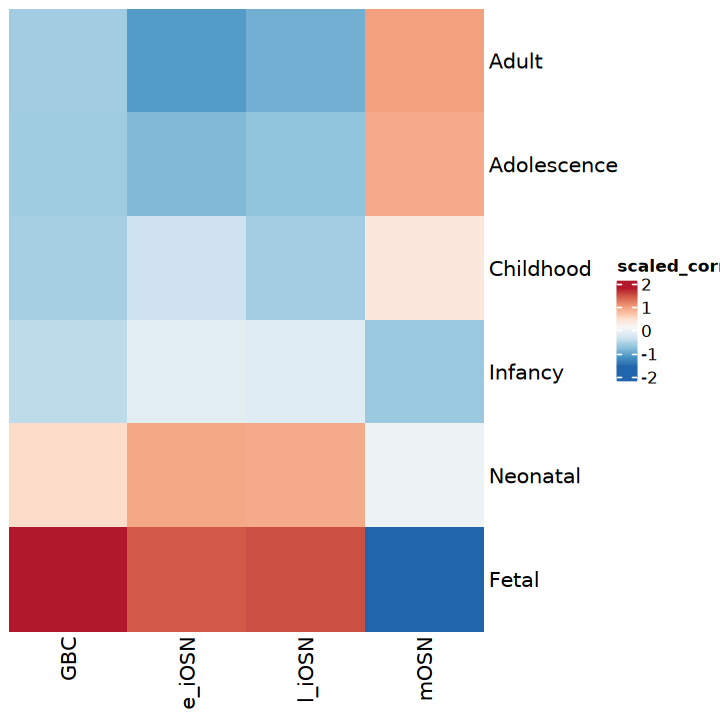

Finding variable features for layer counts

Finding variable features for layer counts



[1] 506


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


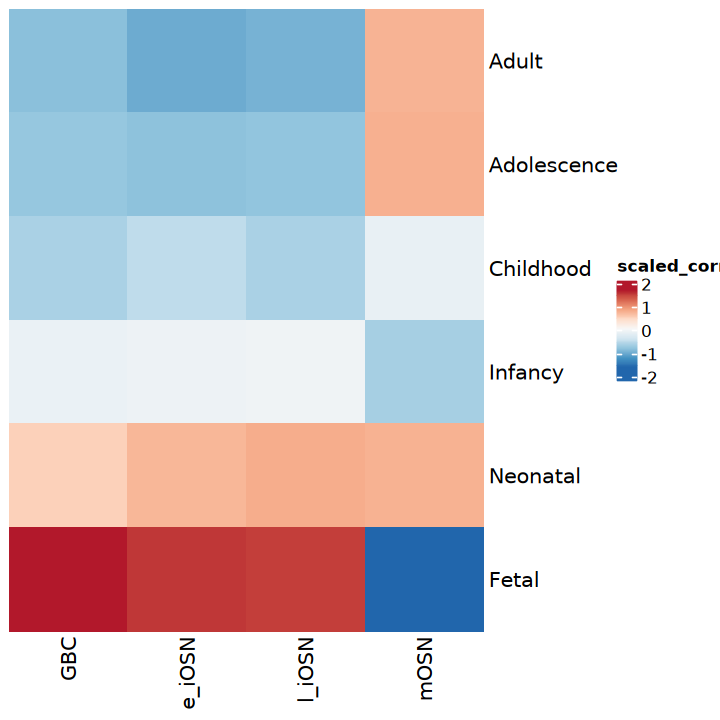

Finding variable features for layer counts

Finding variable features for layer counts



[1] 506


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


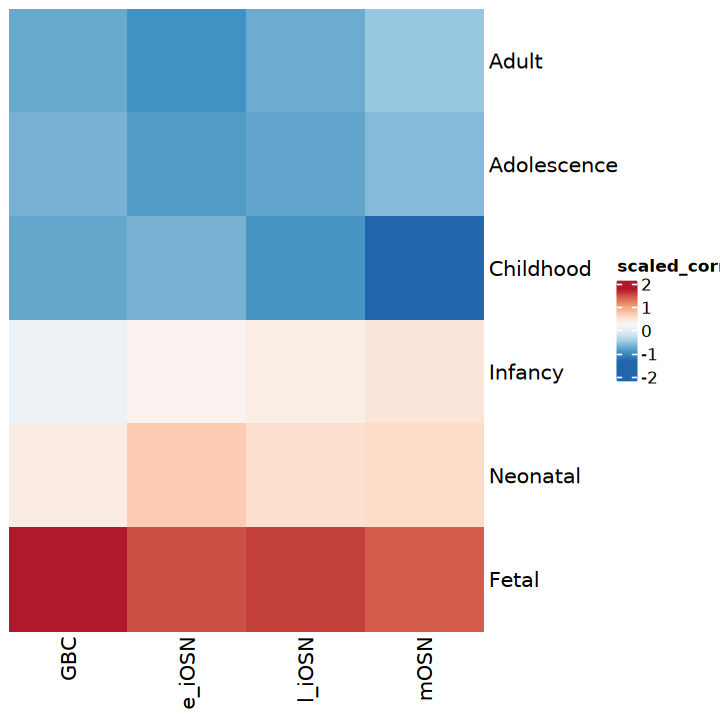

Finding variable features for layer counts

Finding variable features for layer counts



[1] 506


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


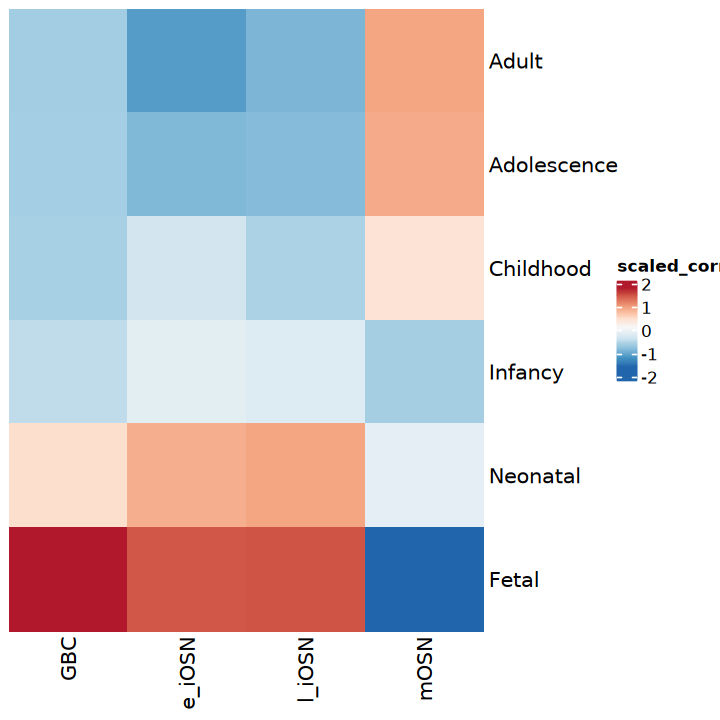

Finding variable features for layer counts

Finding variable features for layer counts



[1] 506


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


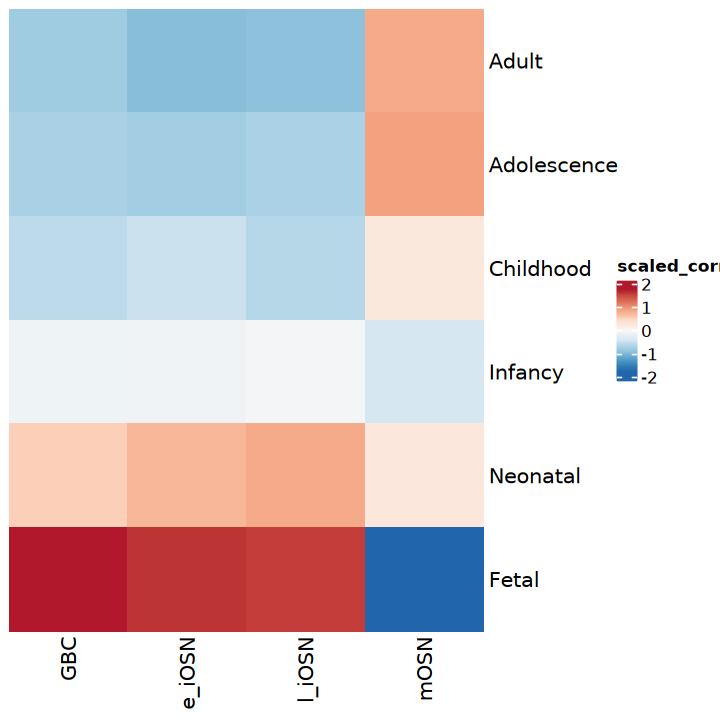

Finding variable features for layer counts

Finding variable features for layer counts



[1] 506


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


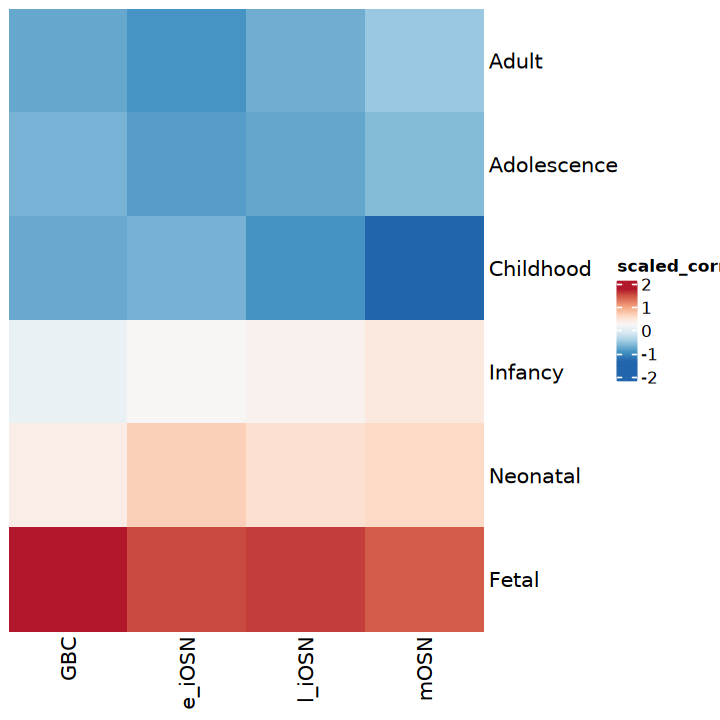

Finding variable features for layer counts

Finding variable features for layer counts



[1] 506


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


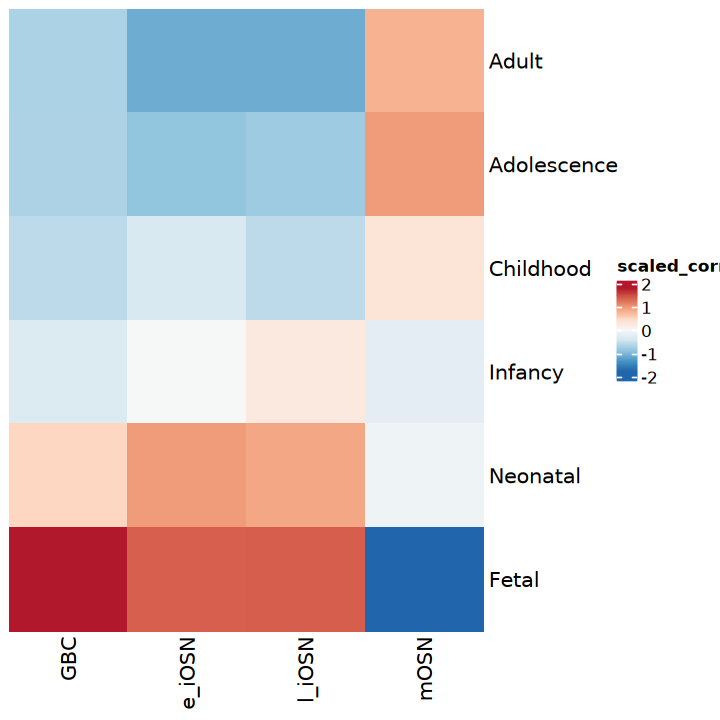

Finding variable features for layer counts

Finding variable features for layer counts



[1] 506


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


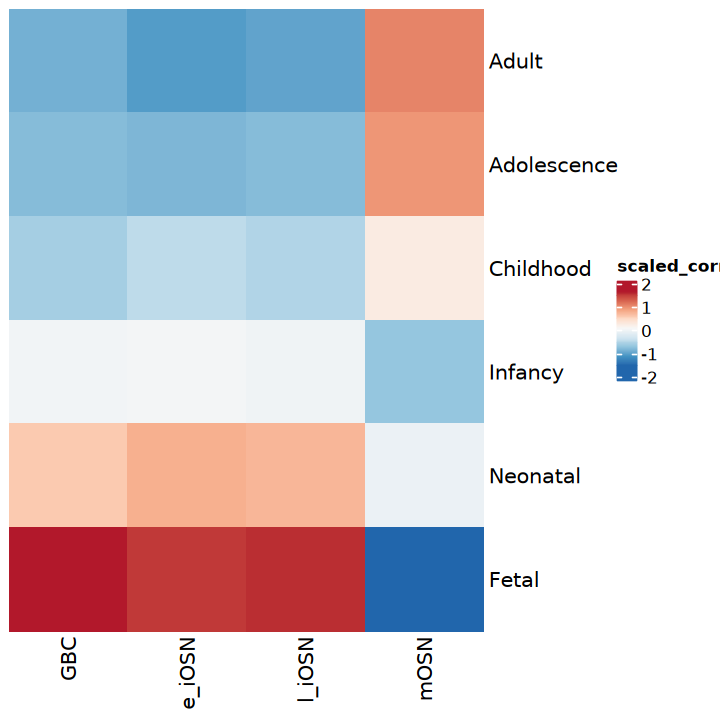

Finding variable features for layer counts

Finding variable features for layer counts



[1] 835


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


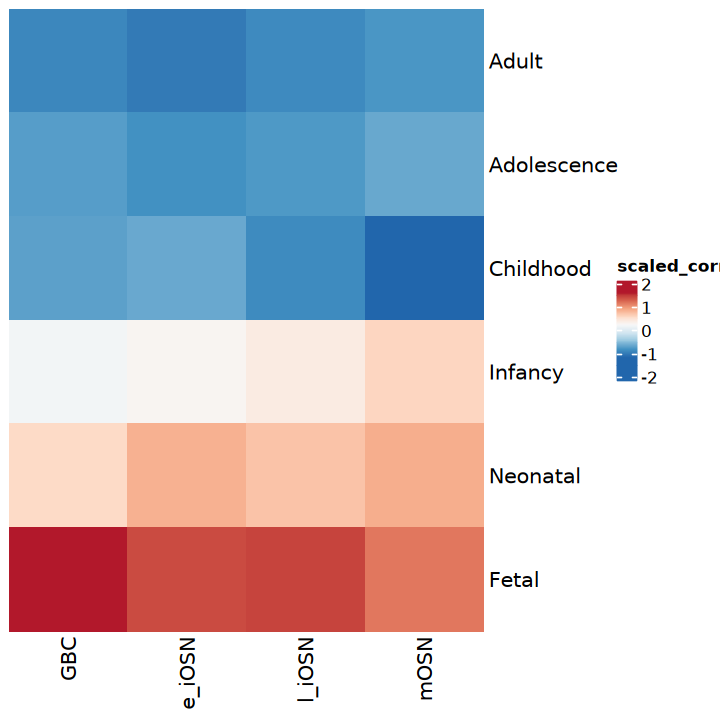

Finding variable features for layer counts

Finding variable features for layer counts



[1] 835


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


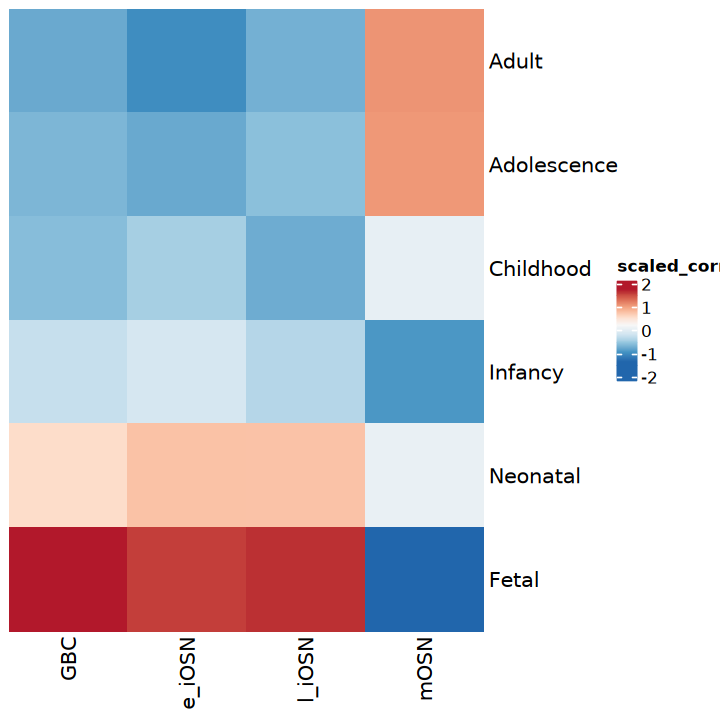

Finding variable features for layer counts

Finding variable features for layer counts



[1] 835


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


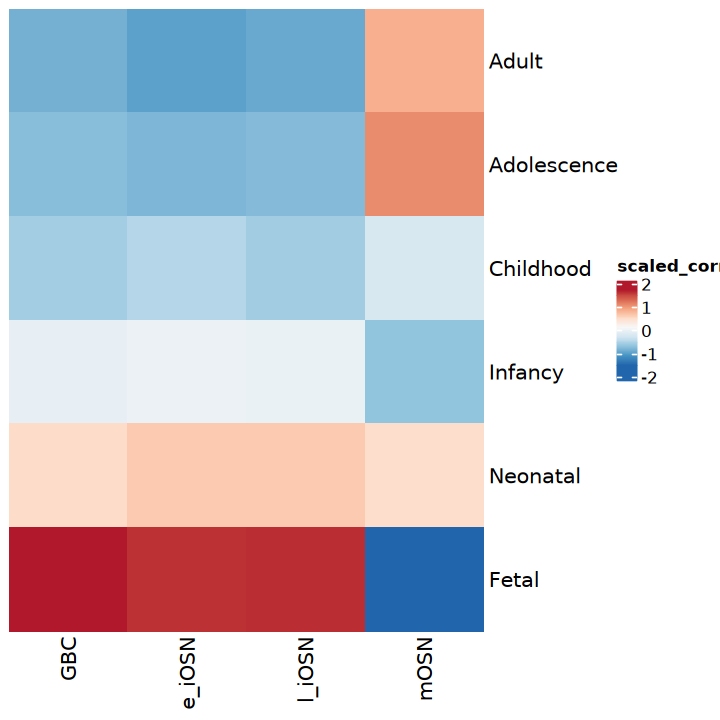

Finding variable features for layer counts

Finding variable features for layer counts



[1] 835


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


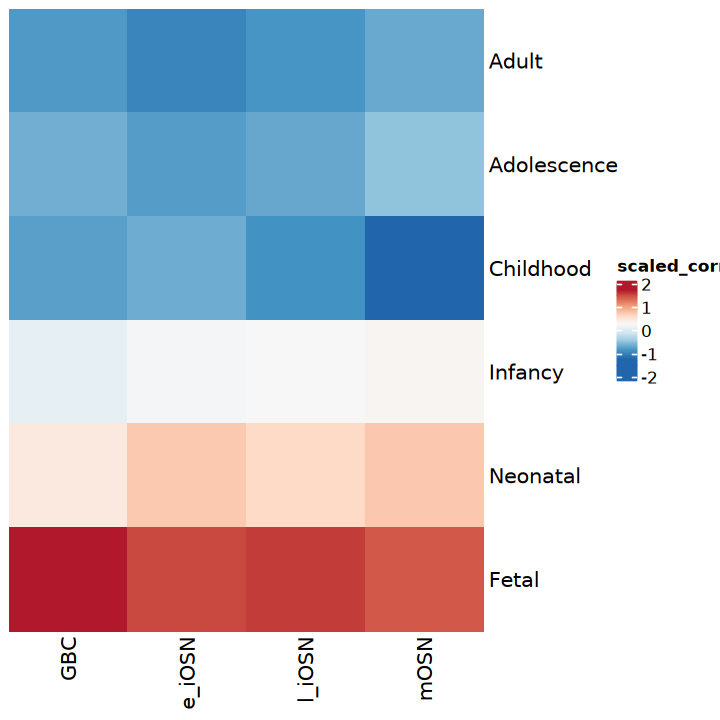

Finding variable features for layer counts

Finding variable features for layer counts



[1] 835


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


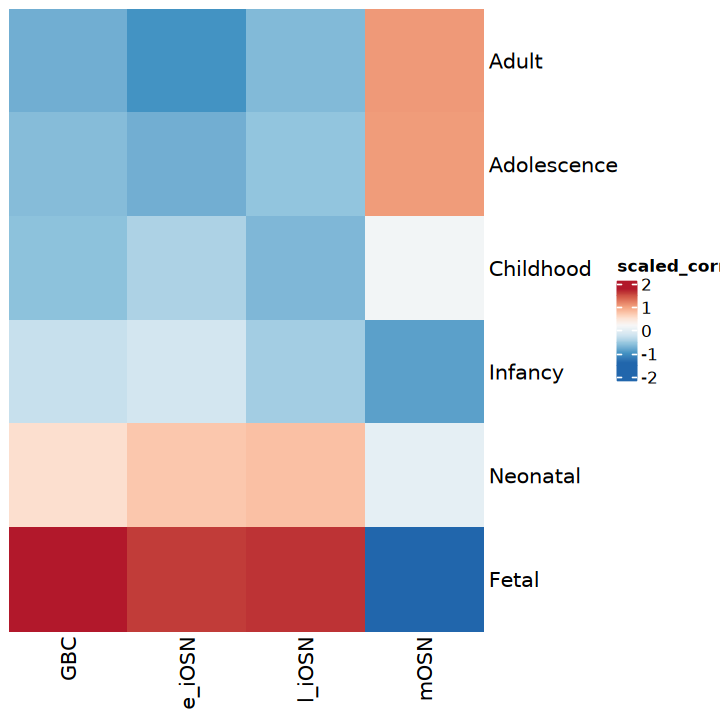

Finding variable features for layer counts

Finding variable features for layer counts



[1] 835


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


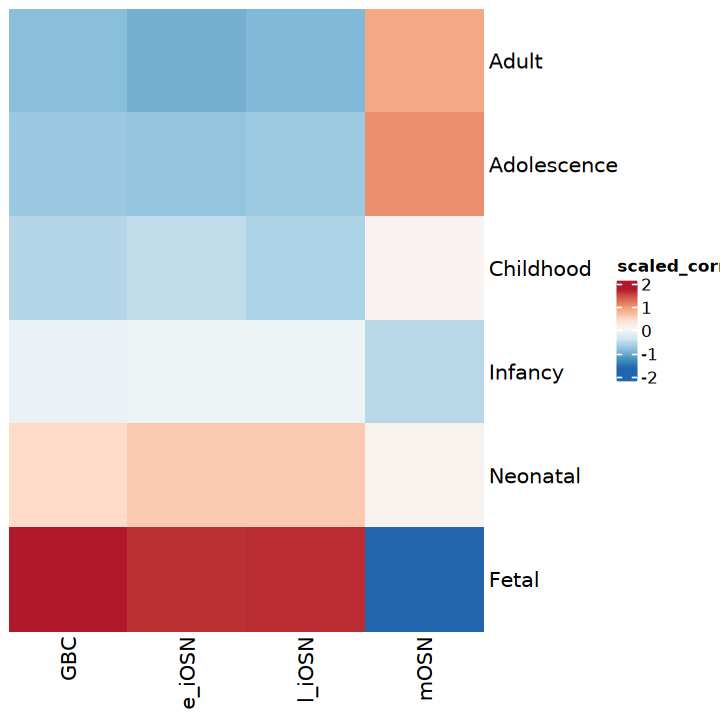

Finding variable features for layer counts

Finding variable features for layer counts



[1] 835


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


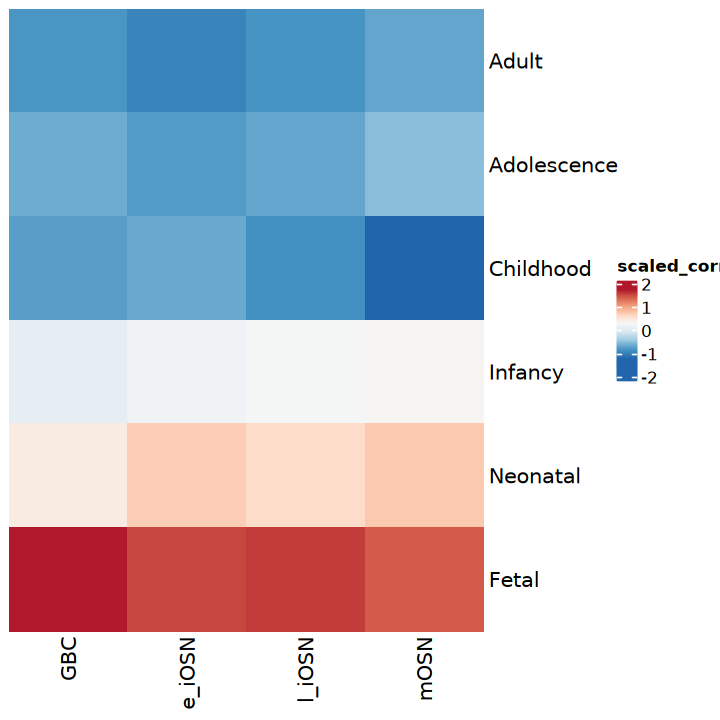

Finding variable features for layer counts

Finding variable features for layer counts



[1] 835


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


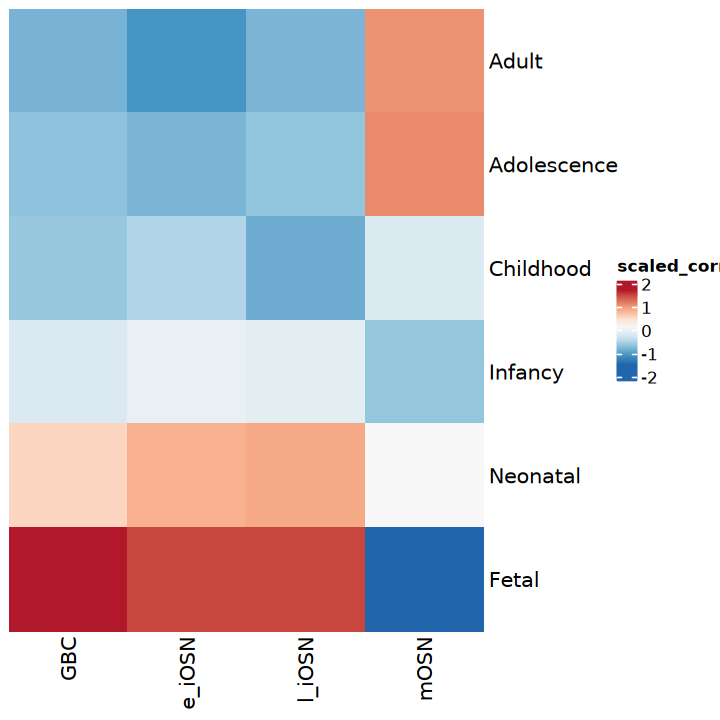

Finding variable features for layer counts

Finding variable features for layer counts



[1] 835


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


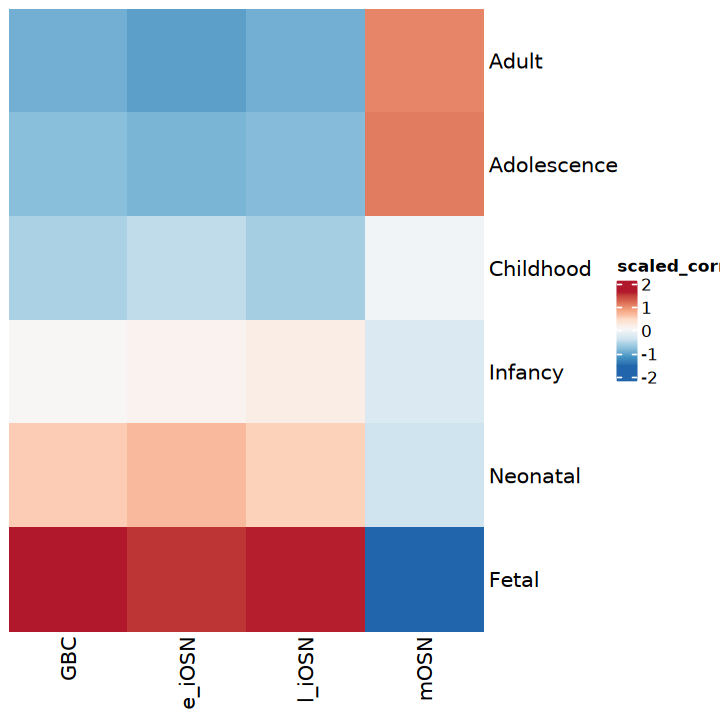

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1233


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


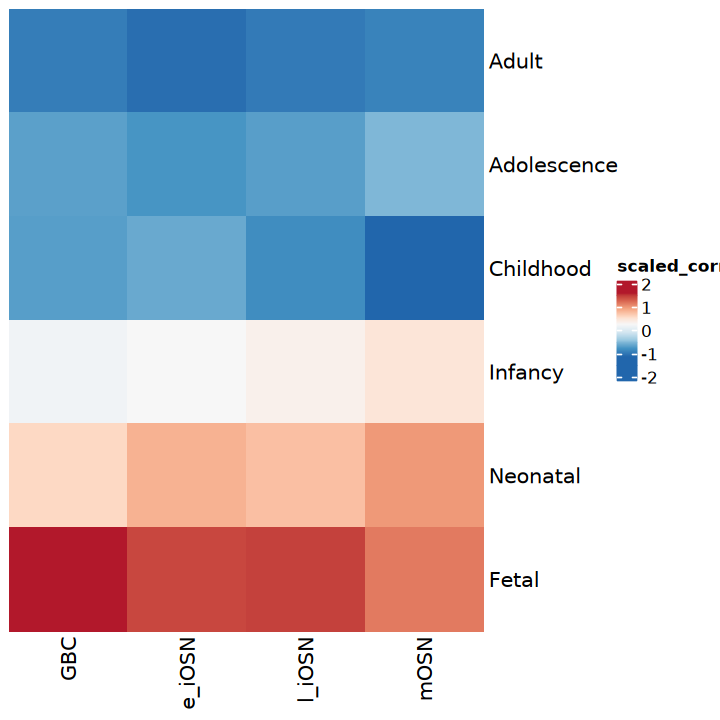

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1233


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


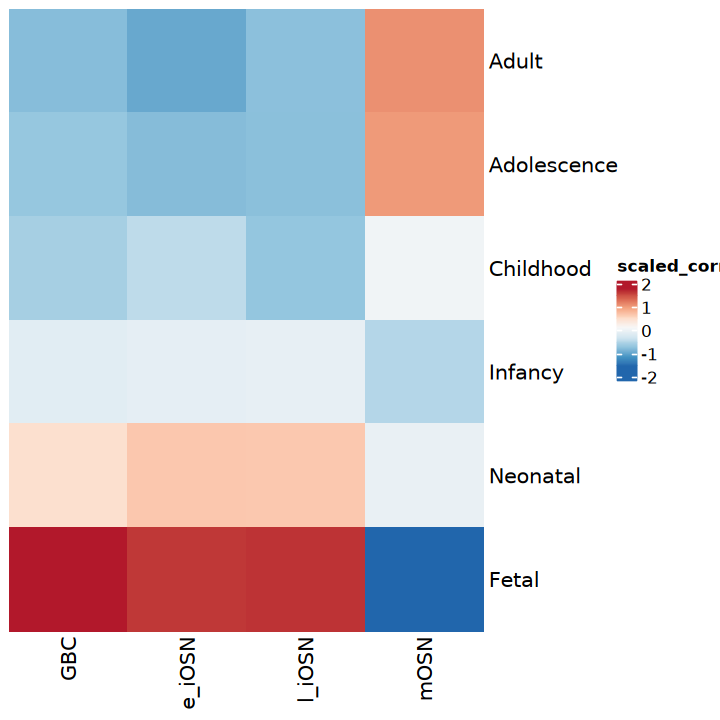

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1233


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


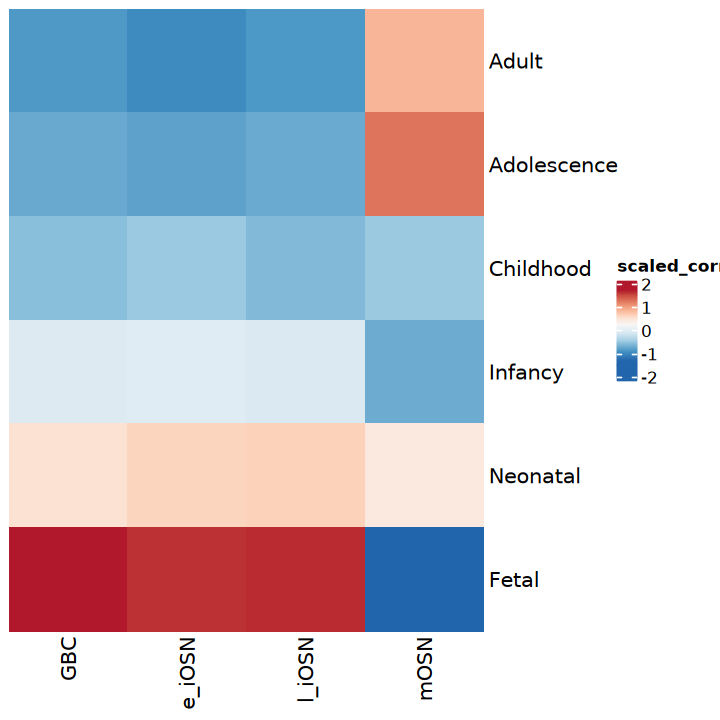

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1233


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


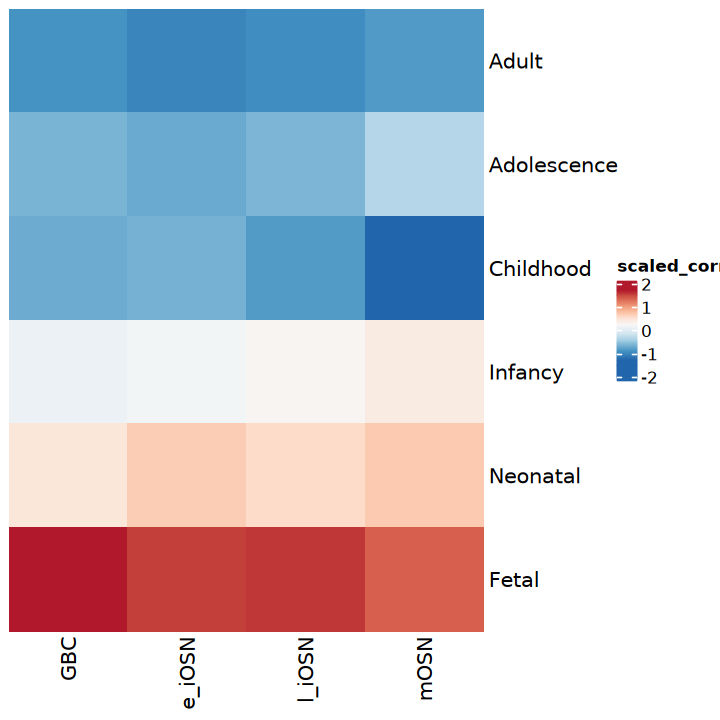

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1233


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


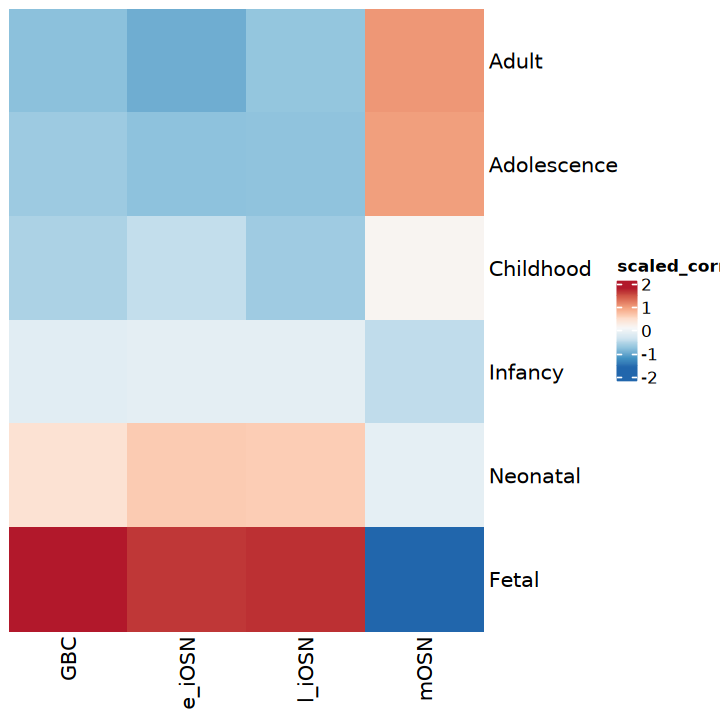

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1233


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


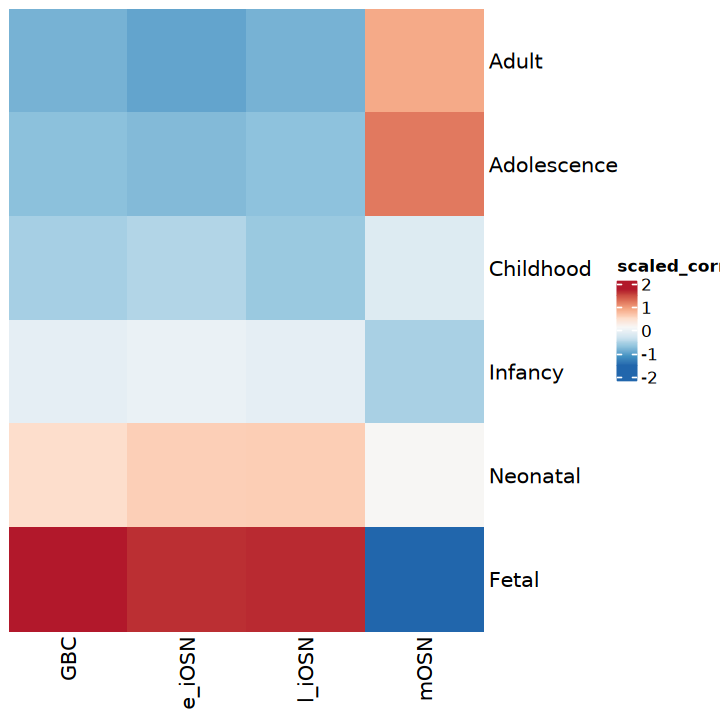

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1233


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


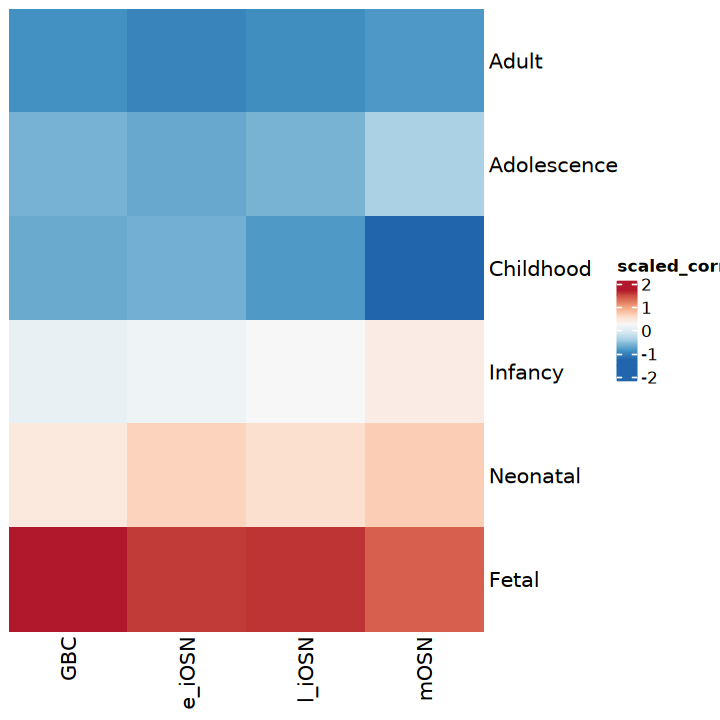

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1233


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


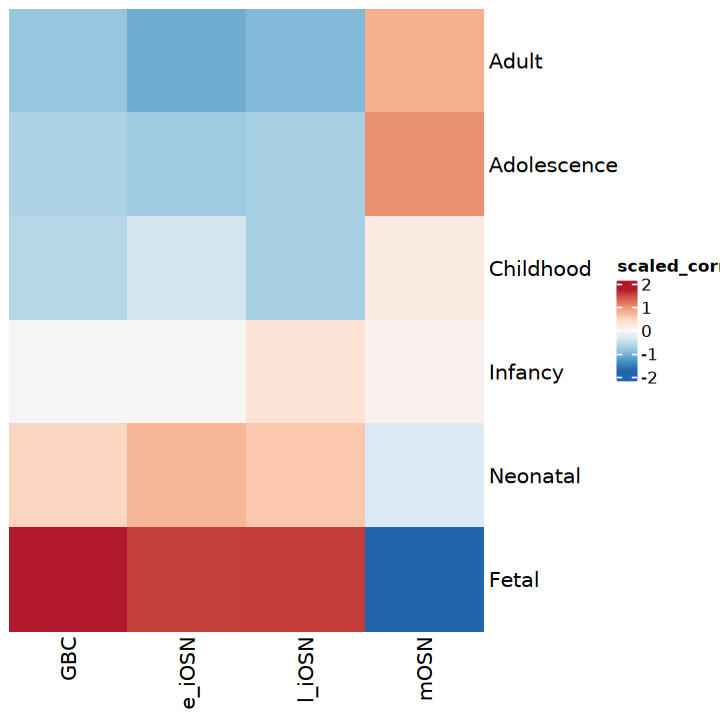

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1233


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


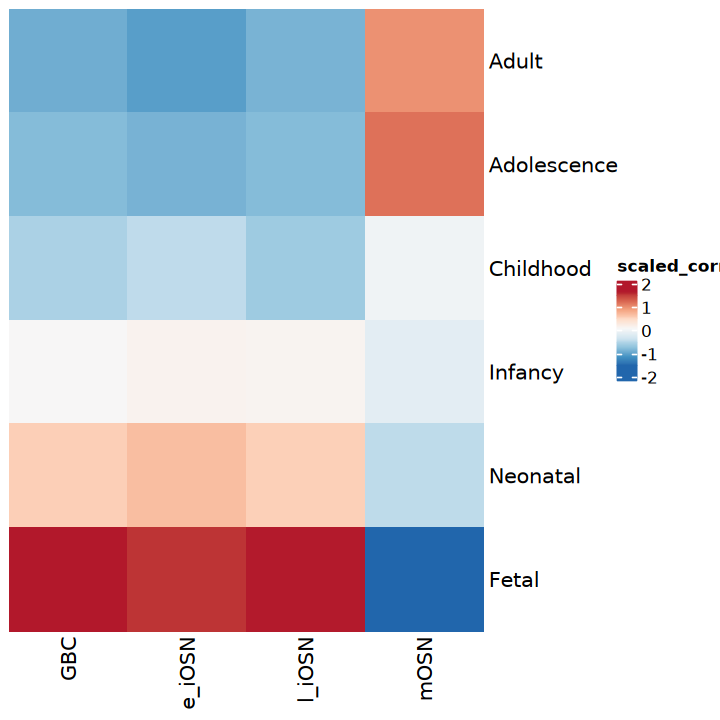

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1640


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


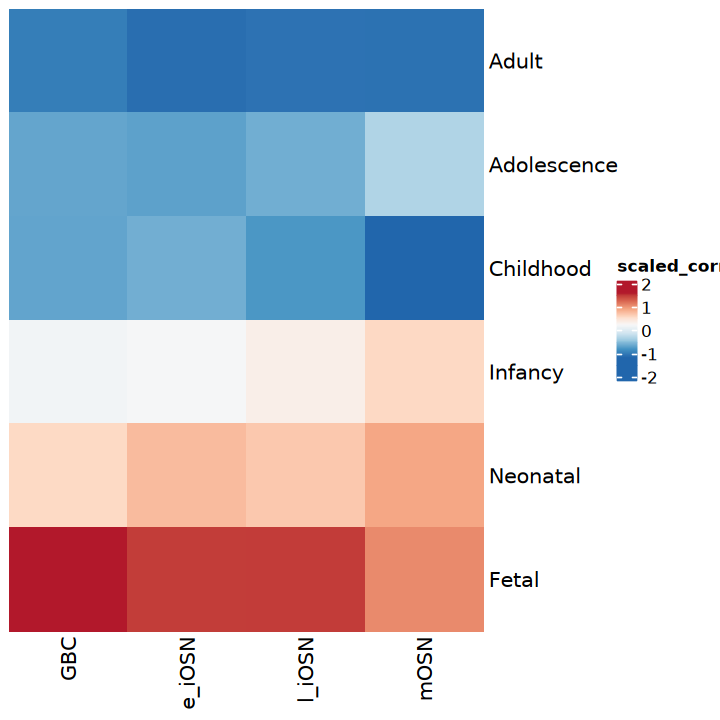

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1640


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


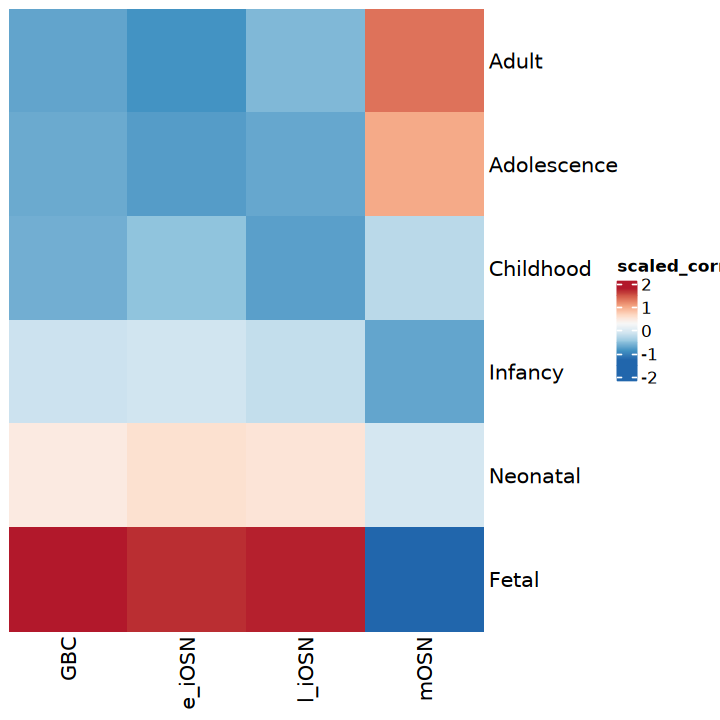

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1640


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


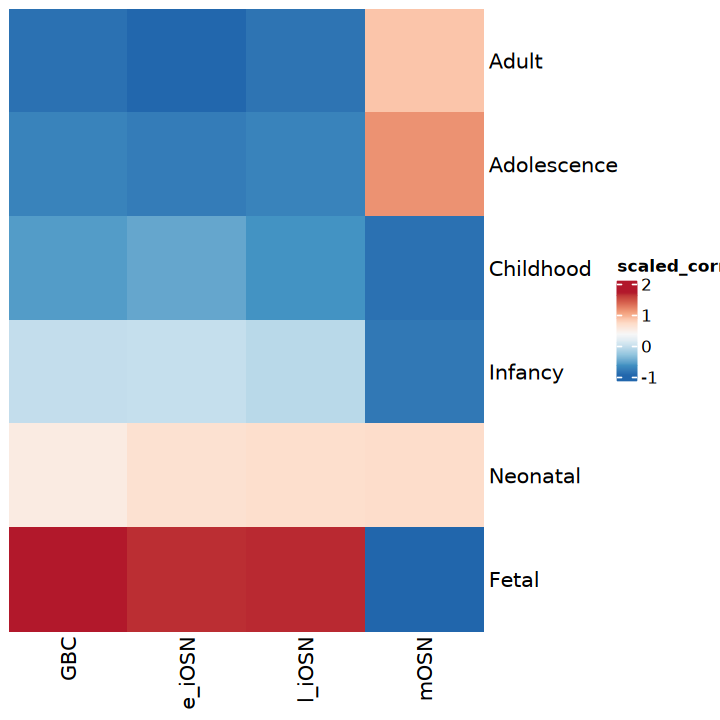

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1640


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


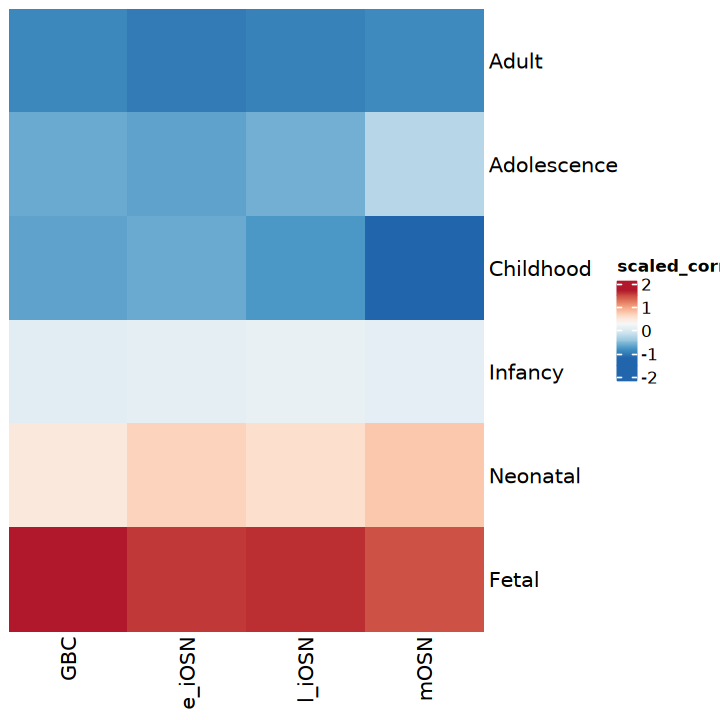

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1640


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


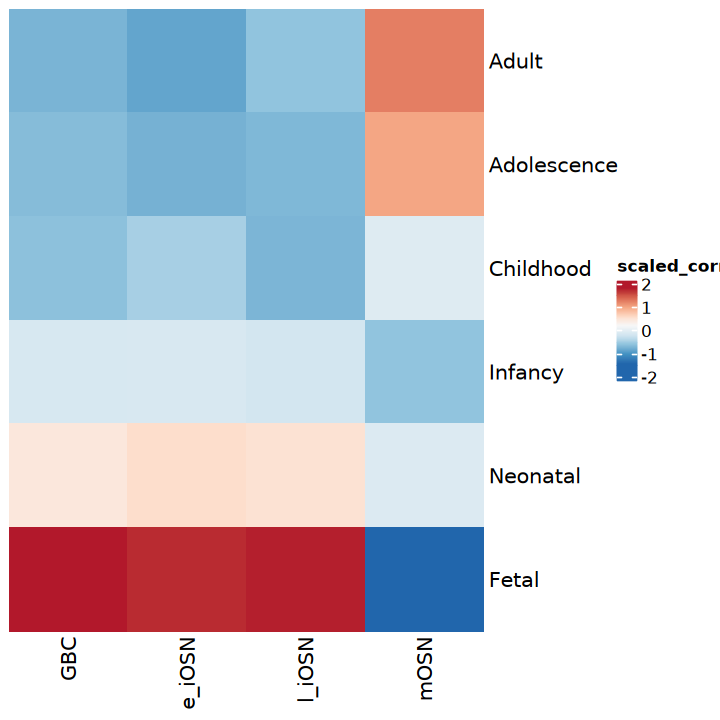

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1640


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


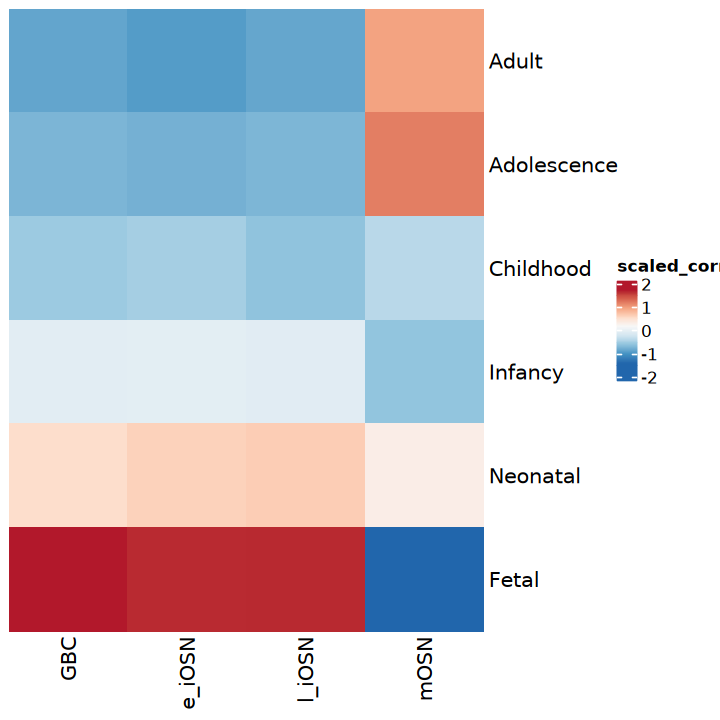

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1640


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


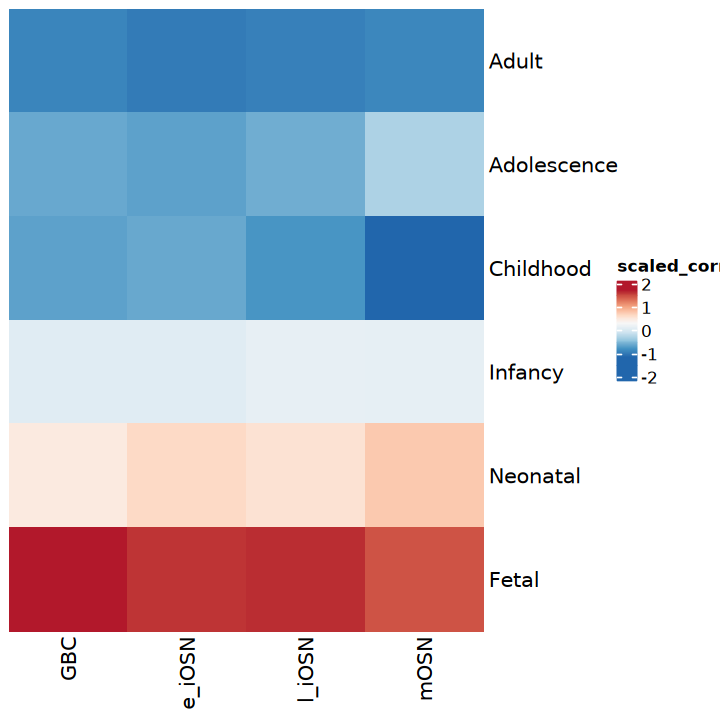

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1640


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


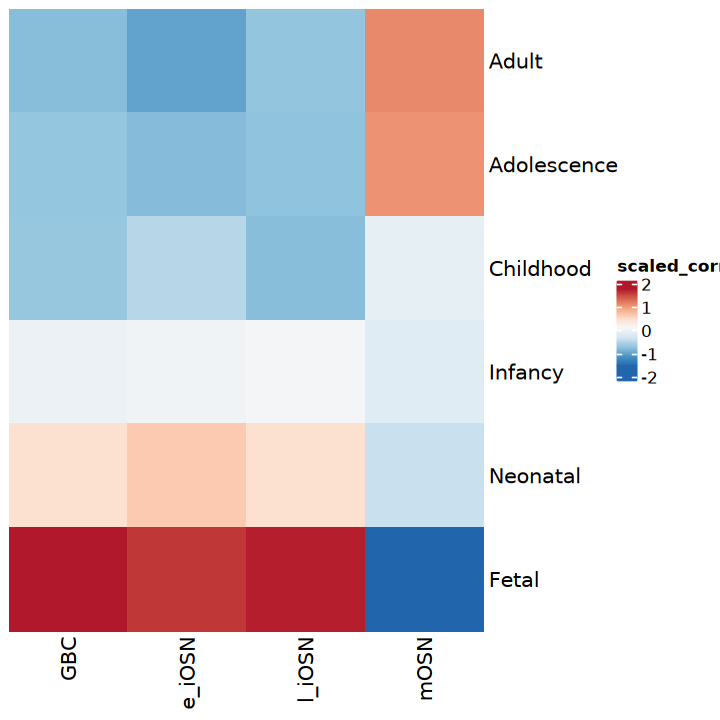

Finding variable features for layer counts

Finding variable features for layer counts



[1] 1640


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


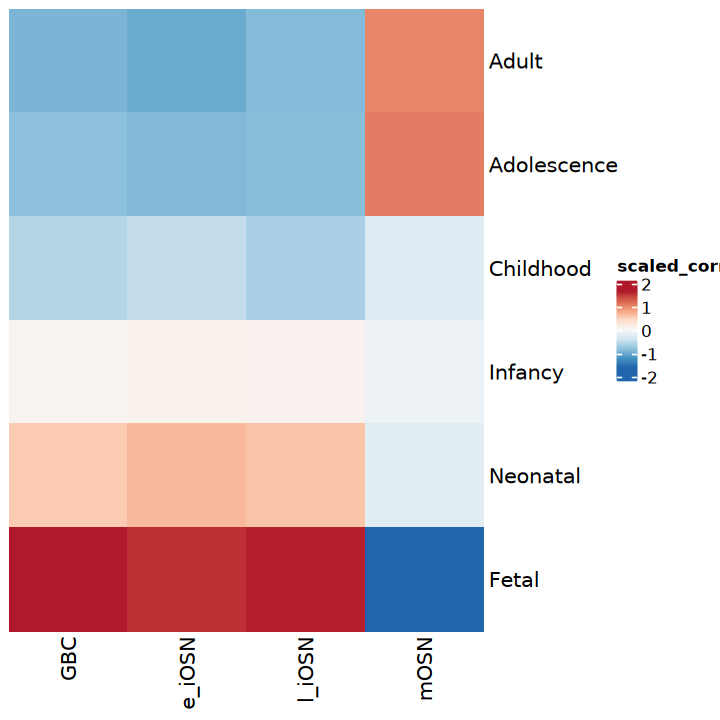

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2026


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


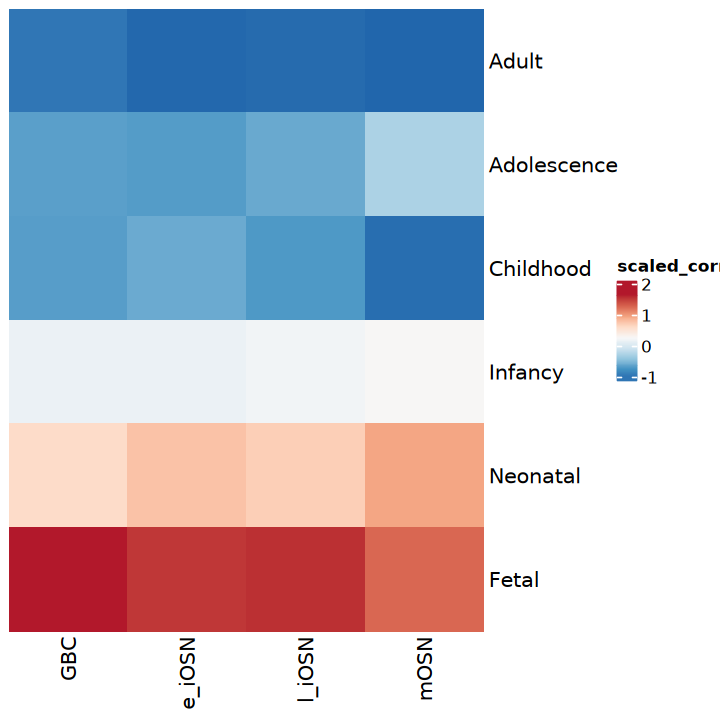

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2026


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


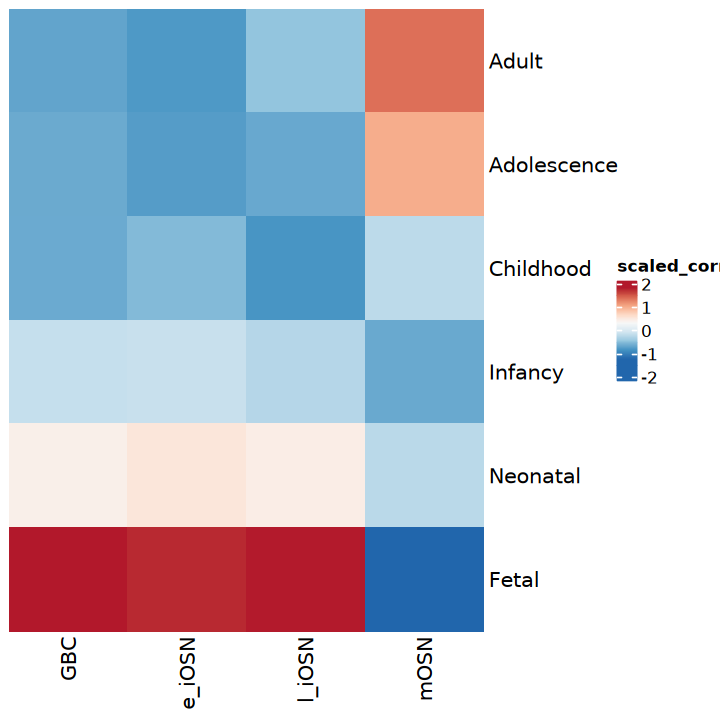

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2026


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


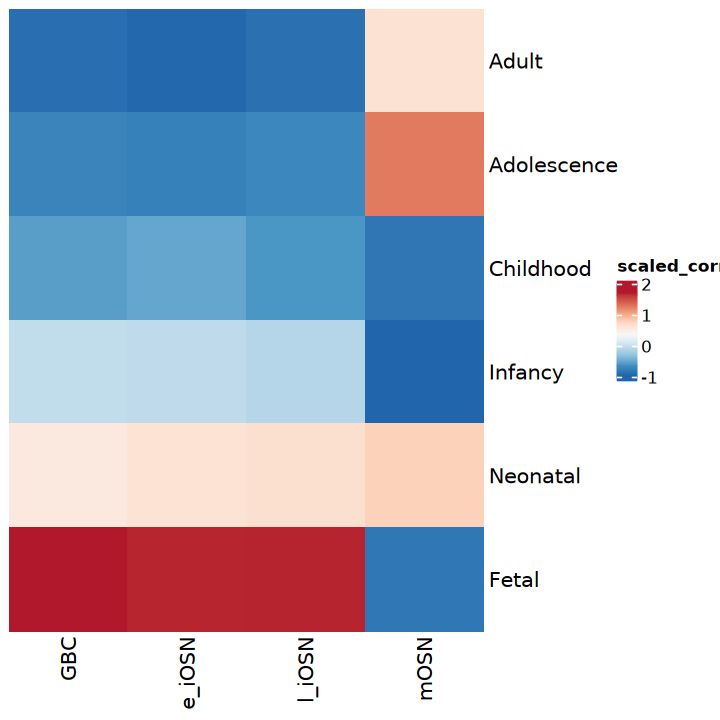

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2026


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


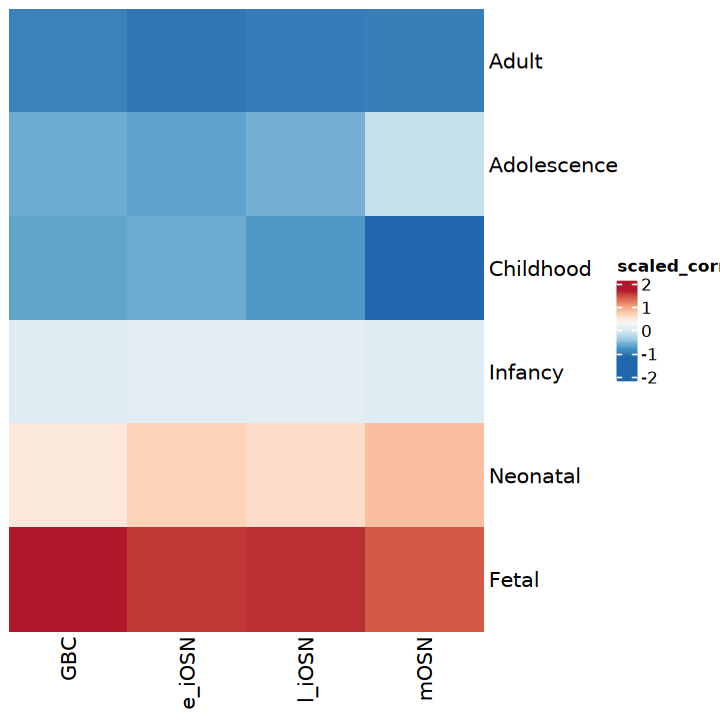

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2026


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


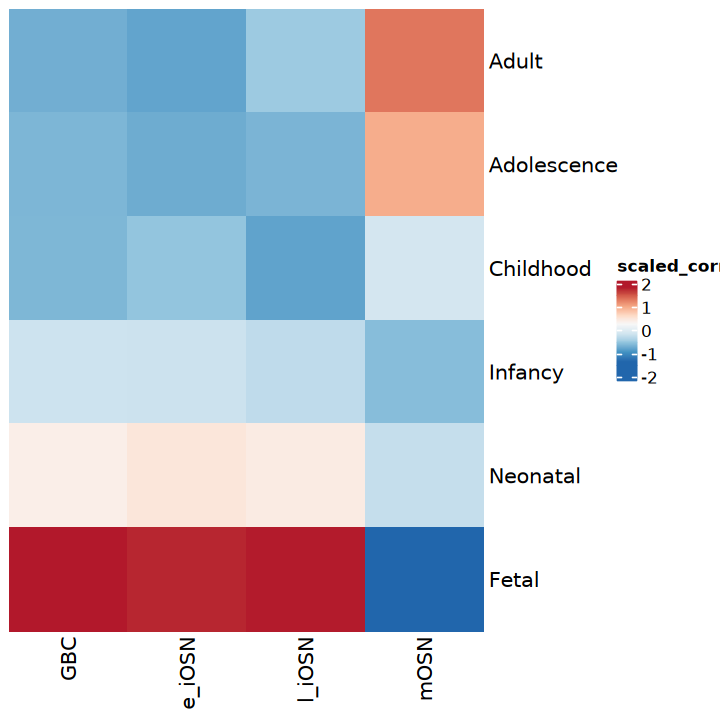

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2026


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


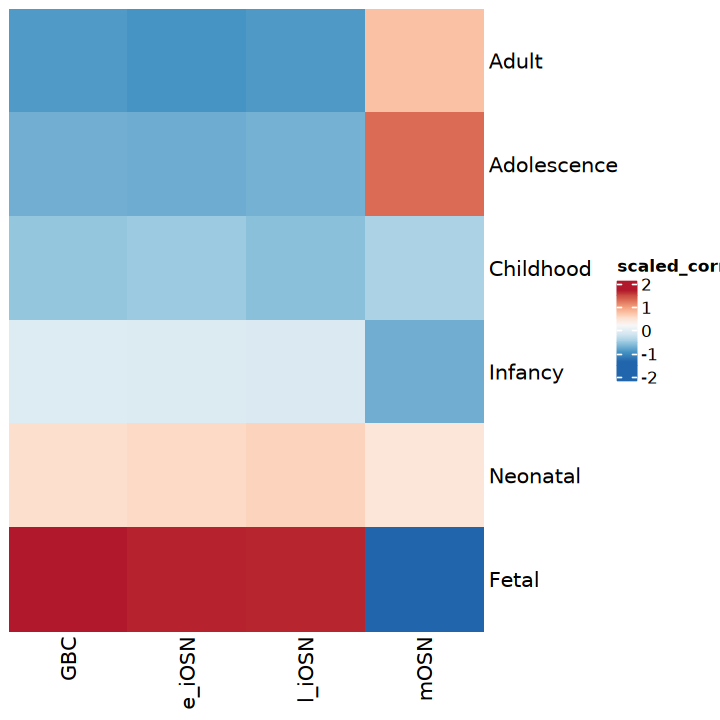

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2026


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


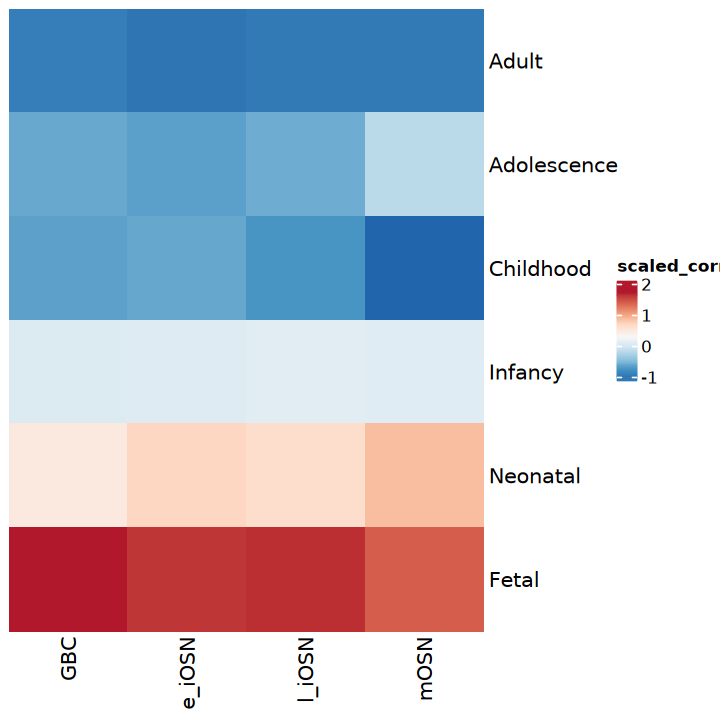

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2026


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


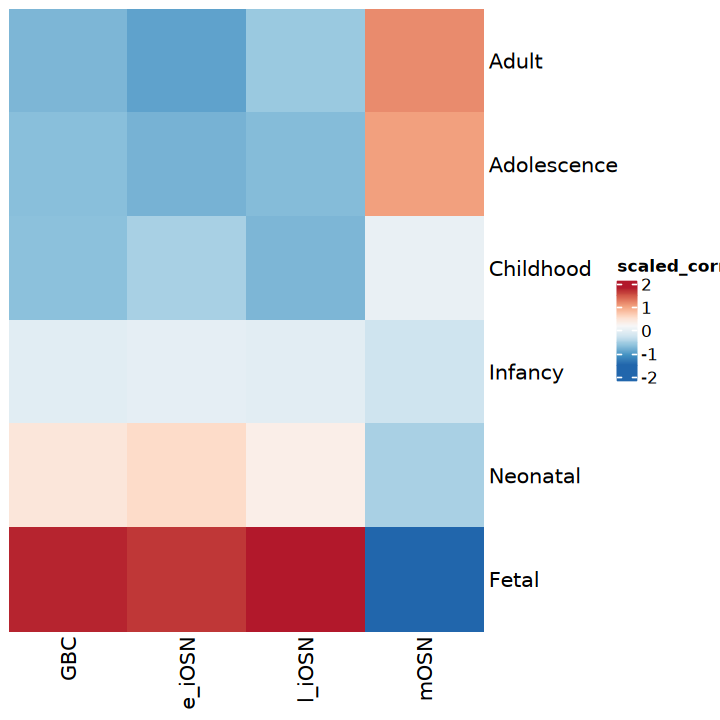

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2026


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


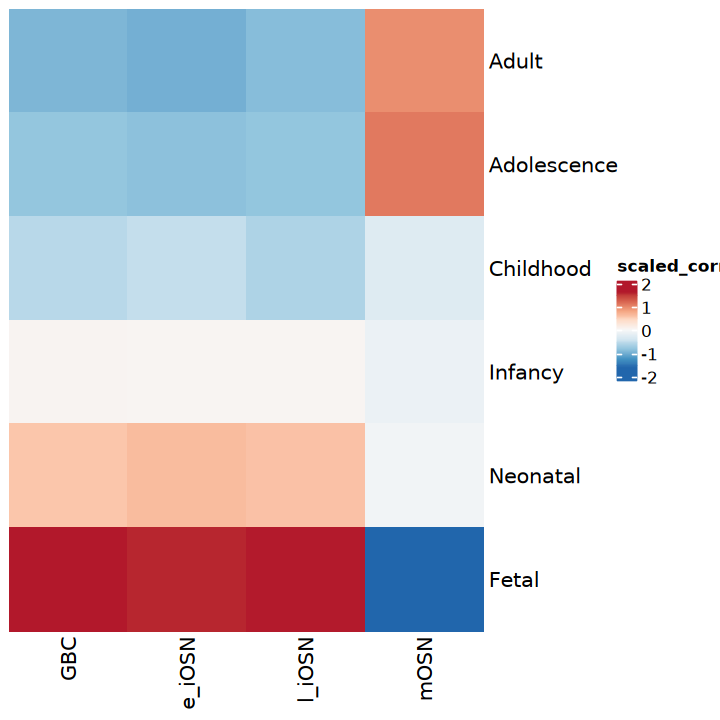

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2381


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


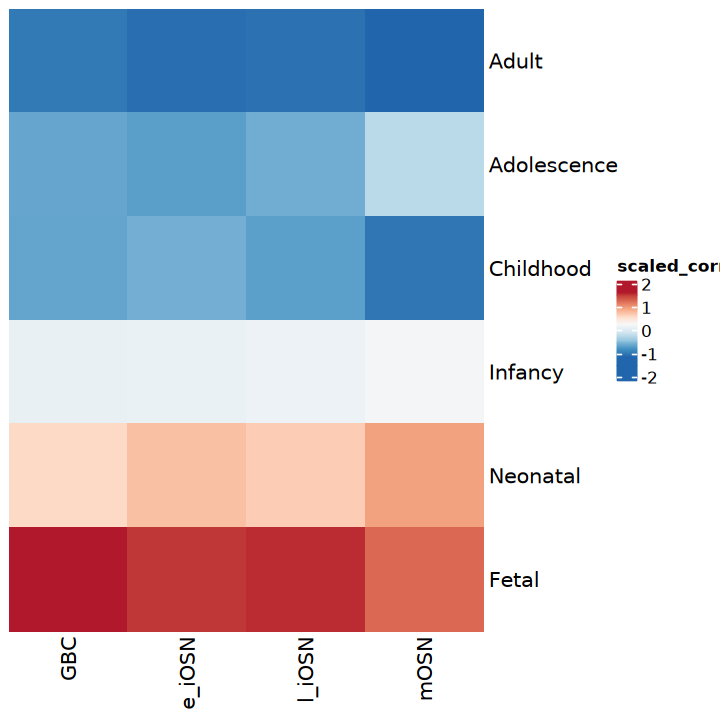

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2381


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


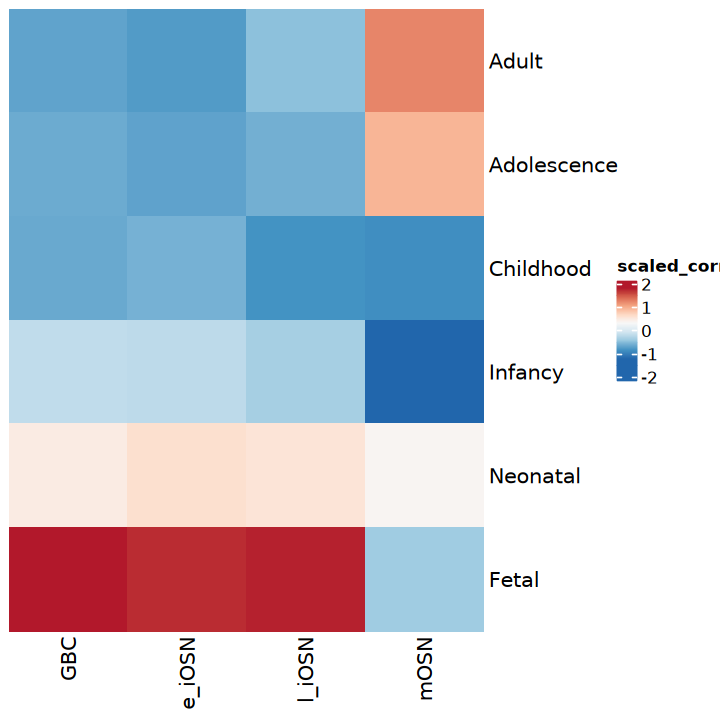

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2381


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


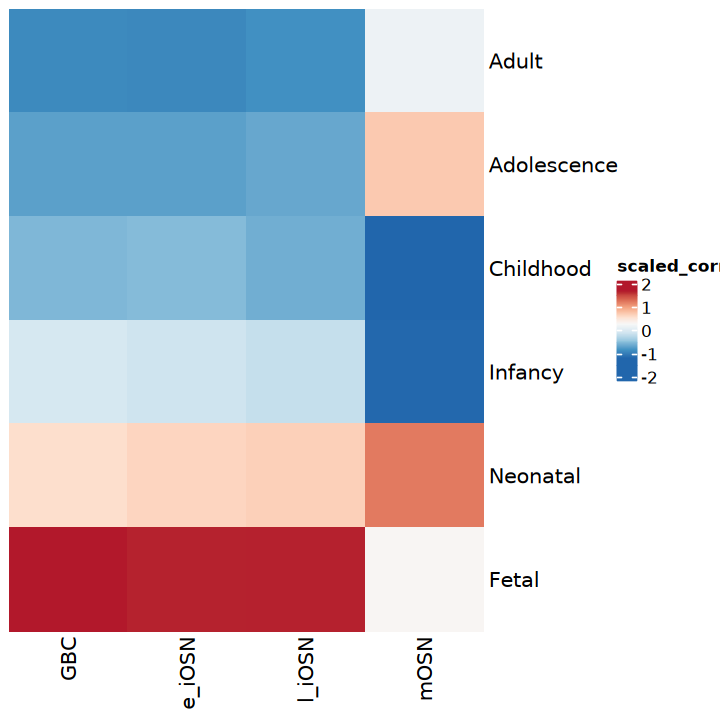

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2381


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


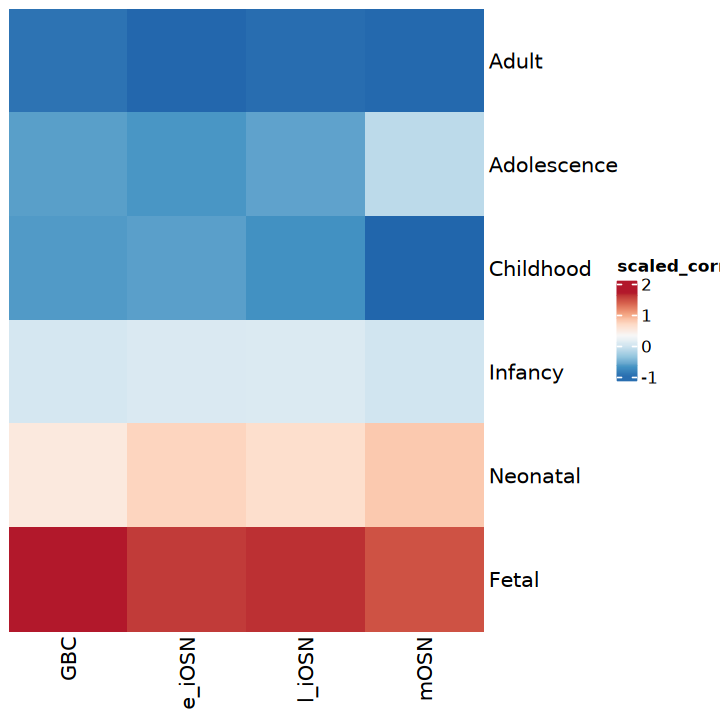

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2381


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


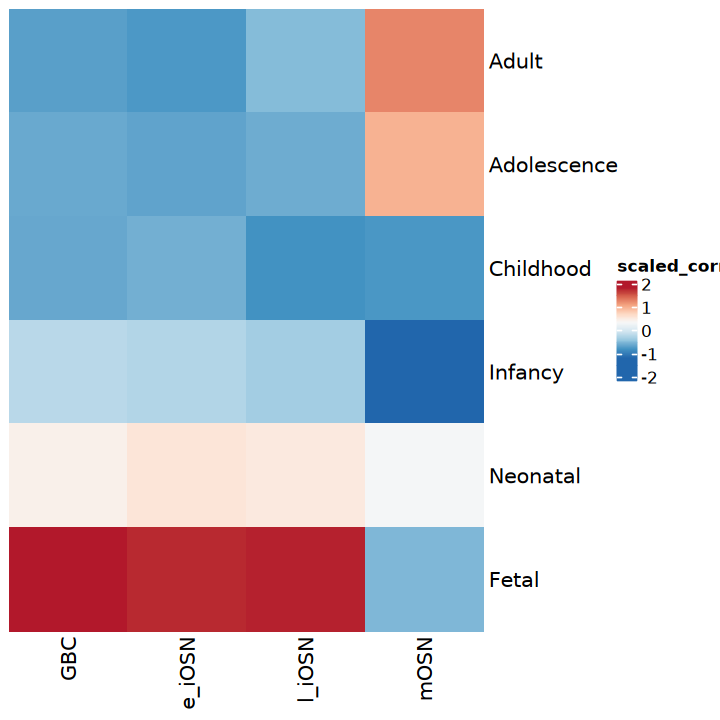

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2381


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


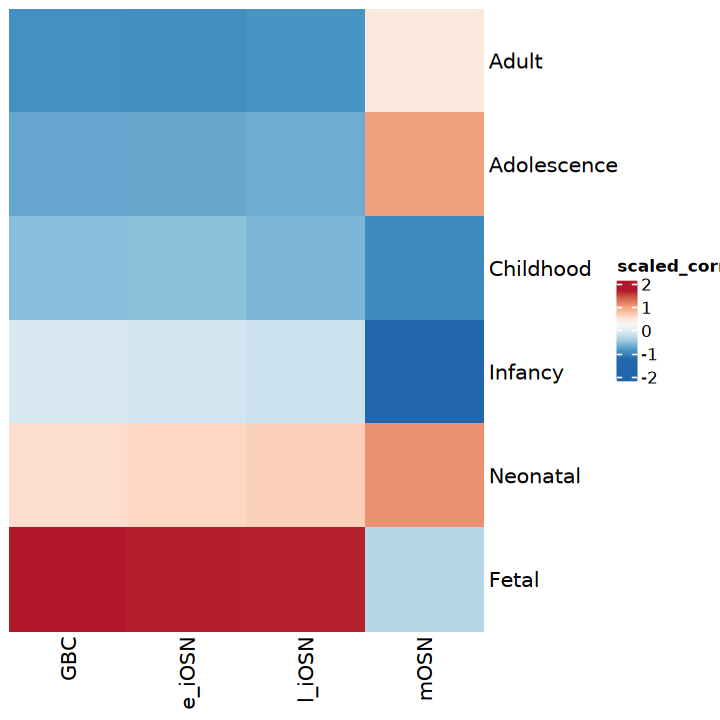

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2381


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


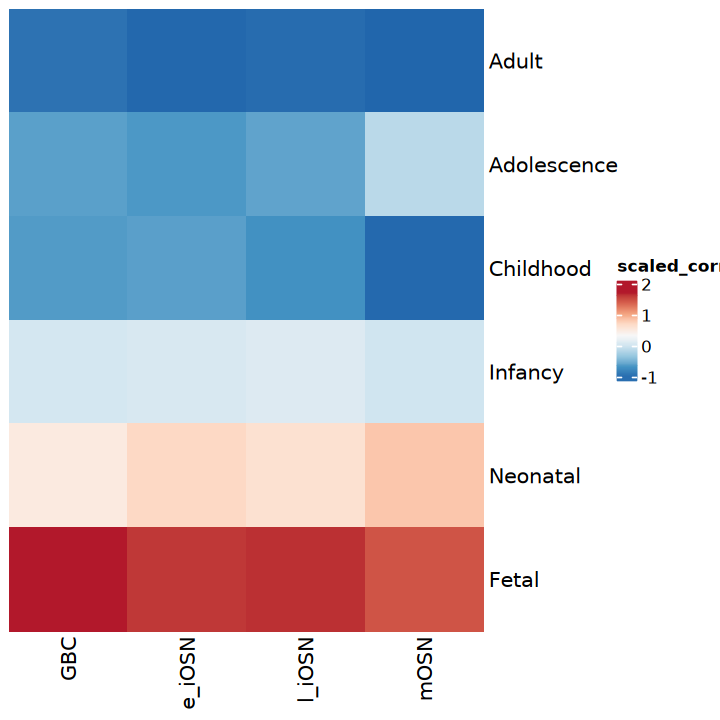

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2381


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


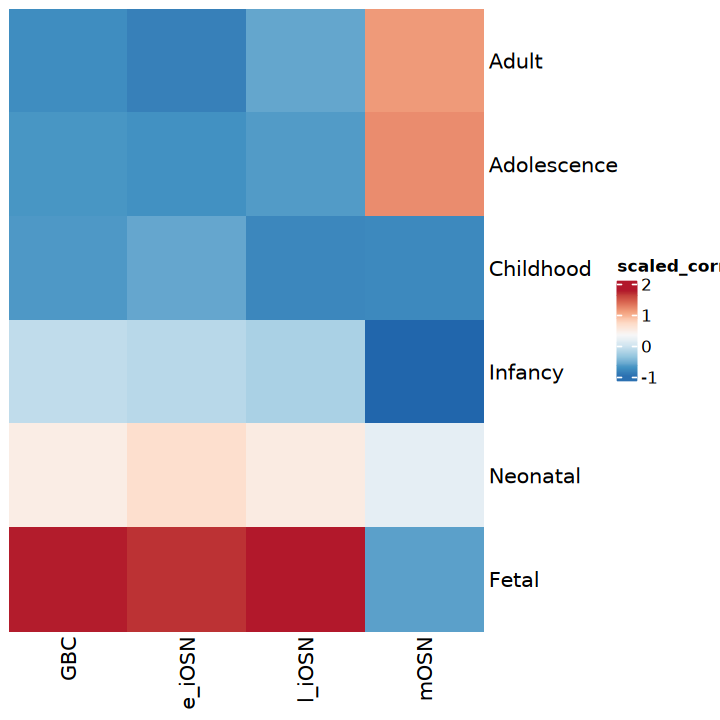

Finding variable features for layer counts

Finding variable features for layer counts



[1] 2381


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


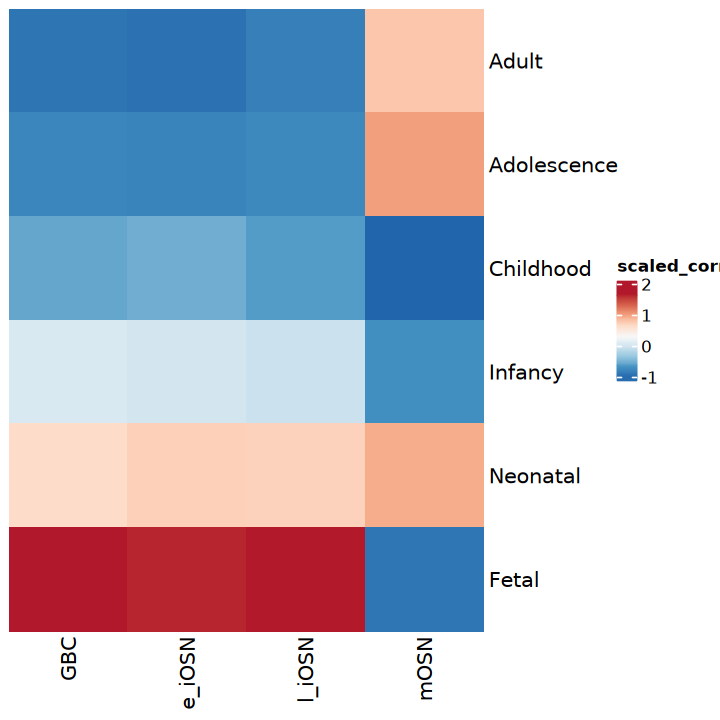

Finding variable features for layer counts

Finding variable features for layer counts



[1] 3649


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


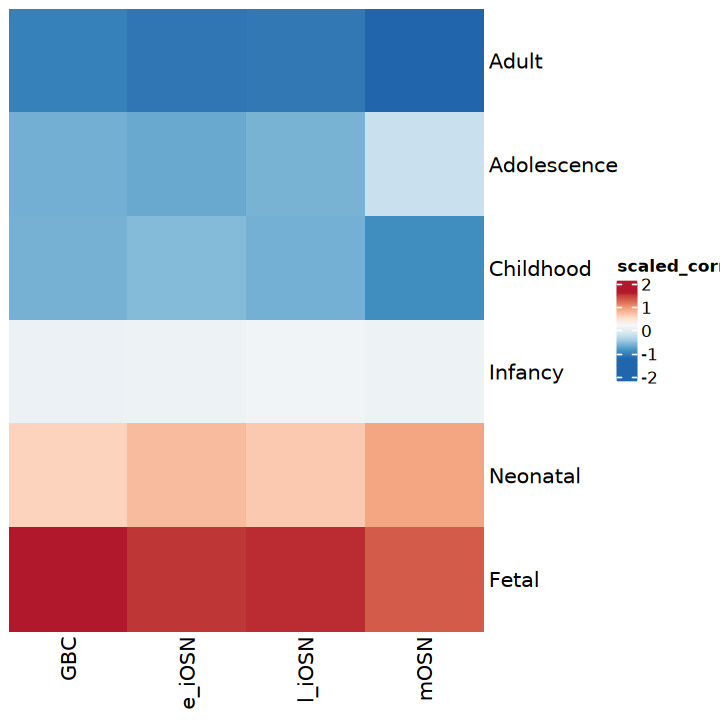

Finding variable features for layer counts

Finding variable features for layer counts



[1] 3649


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


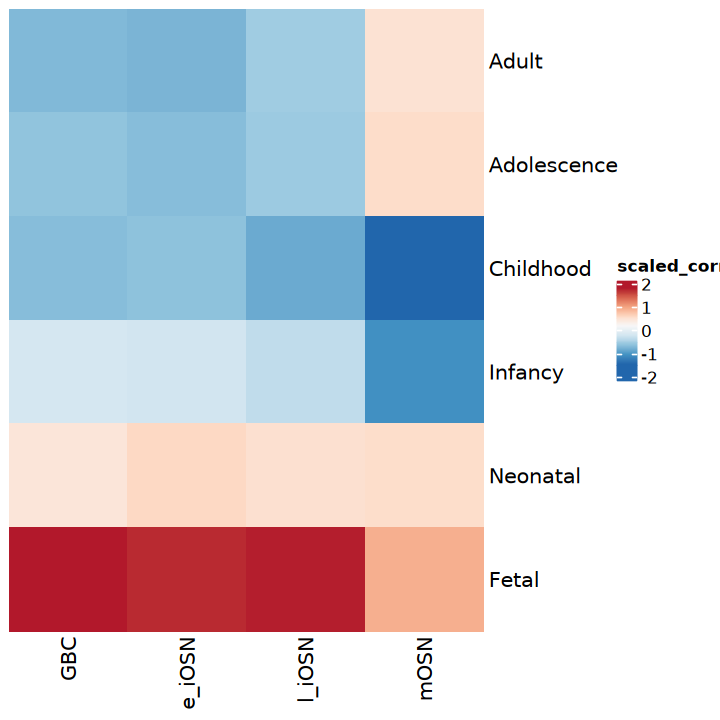

Finding variable features for layer counts

Finding variable features for layer counts



[1] 3649


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


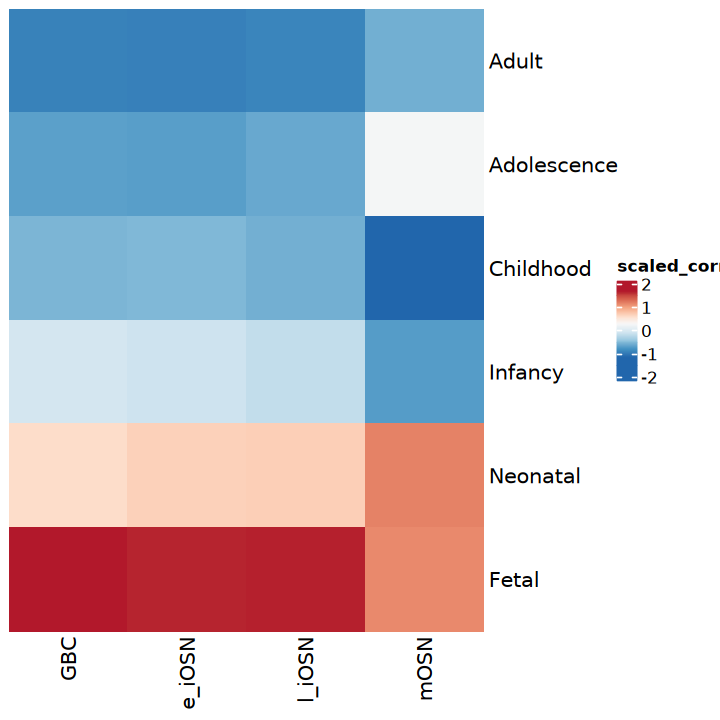

Finding variable features for layer counts

Finding variable features for layer counts



[1] 3649


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


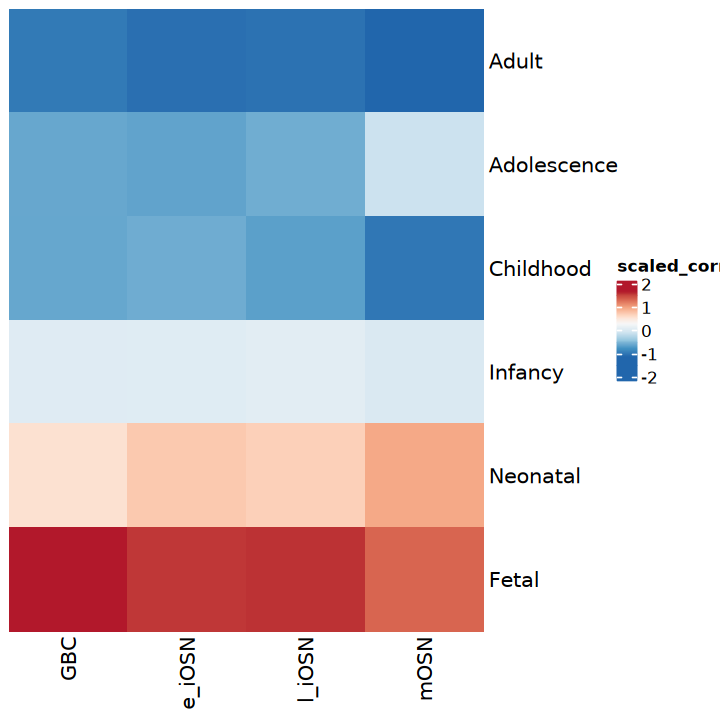

Finding variable features for layer counts

Finding variable features for layer counts



[1] 3649


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


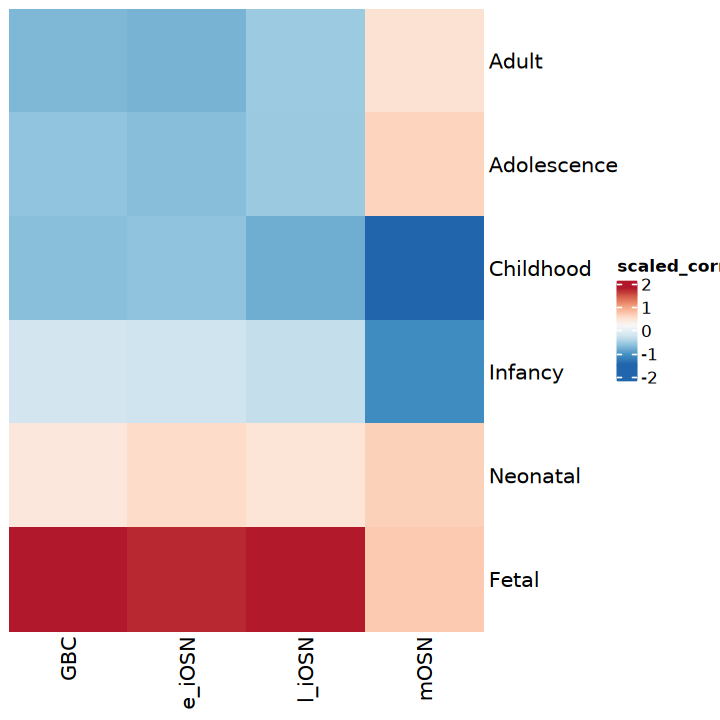

Finding variable features for layer counts

Finding variable features for layer counts



[1] 3649


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


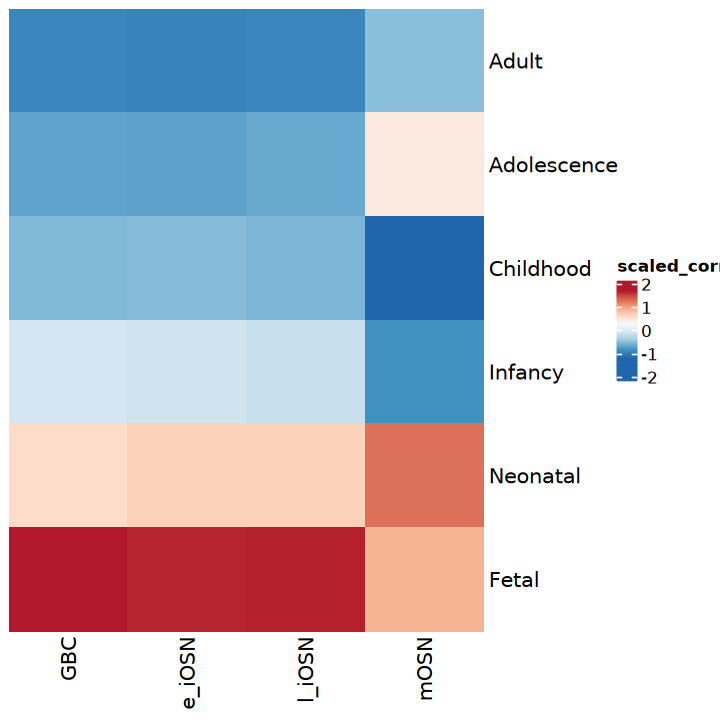

Finding variable features for layer counts

Finding variable features for layer counts



[1] 3649


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


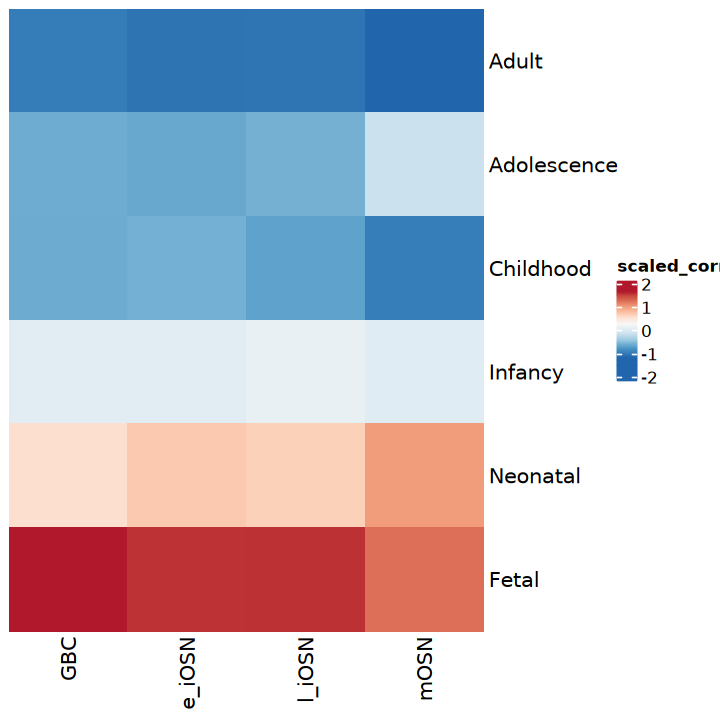

Finding variable features for layer counts

Finding variable features for layer counts



[1] 3649


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


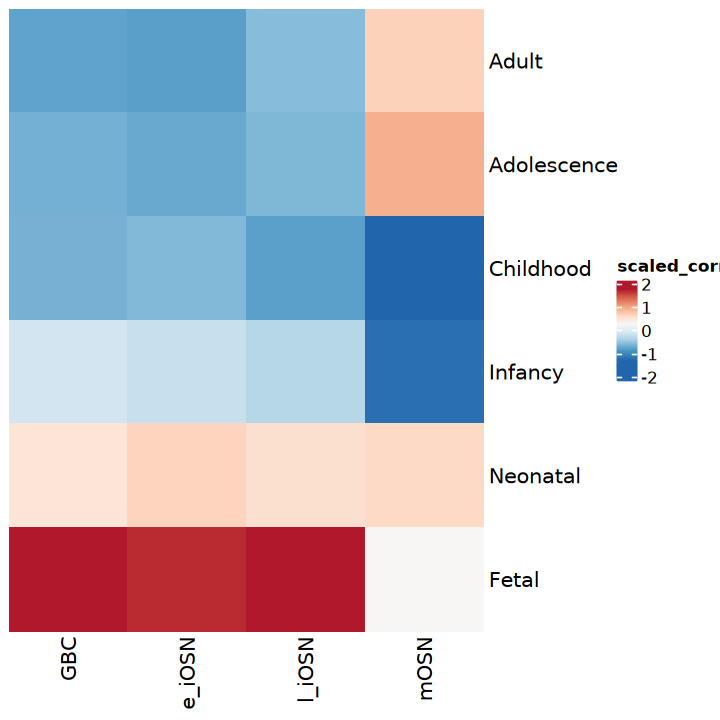

Finding variable features for layer counts

Finding variable features for layer counts



[1] 3649


Warning message in geom_tile(aes(mapping = corr_he)):
“Ignoring unknown aesthetics: mapping”


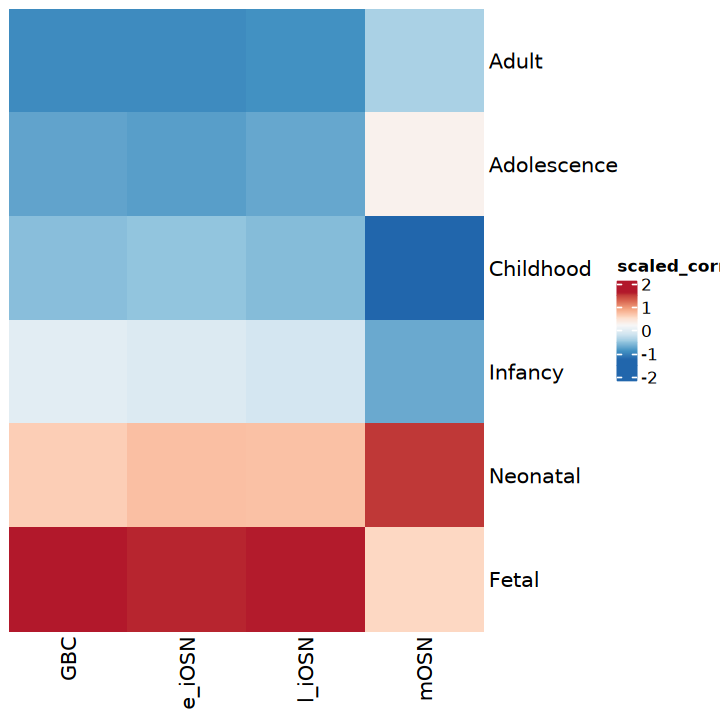

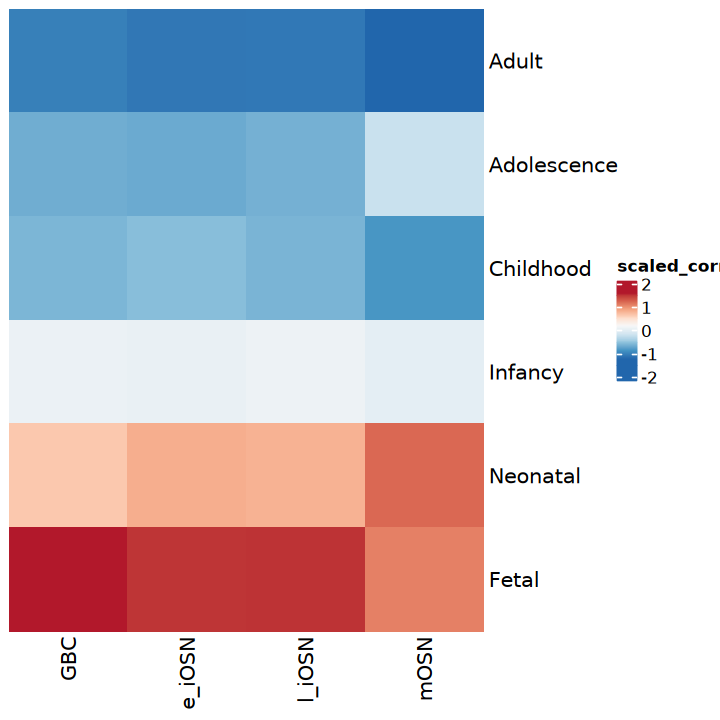

In [35]:
for (nf in c(2000,3000,4000,5000,6000,7000,10000)){
    for (cor_md in c('spearman','kendall','pearson')){
        for (hvg in c('HVG','HVG_ent','HVG_en')){
            
        ExN_data <- FindVariableFeatures(ExN_data, nfeatures = nf)
        ent_N <- FindVariableFeatures(ent_N, nfeatures = nf) # for identify DEGs using slingshot
        print(length(intersect( VariableFeatures(ExN_data), VariableFeatures(ent_N))))
        corr_he <- c()
        for (ct1 in colnames(pseudo_cluster_ENT)){
            for (ct2 in colnames(pseudo_cluster)){

                if(hvg=='HVG'){ intersect_genes <- intersect(VariableFeatures(ExN_data),VariableFeatures(ent_N))}
                if(hvg=='HVG_ent'){ intersect_genes <- intersect( rownames(ExN_data), VariableFeatures(ent_N))}
                if(hvg=='HVG_en'){ intersect_genes <- intersect( VariableFeatures(ExN_data), rownames(ent_N))}

                pseudo_clusterx <- pseudo_cluster[intersect_genes,ct2]
                pseudo_cluster_ENTx <- pseudo_cluster_ENT[intersect_genes,ct1]
                x= cor(pseudo_clusterx,pseudo_cluster_ENTx,method = cor_md)
                names(x) <- paste(ct1,ct2)
                corr_he <- c(corr_he,x)
            } 
        }

corr_he <- as.data.frame(corr_he)
corr_he$OSN <- str_split(rownames(corr_he),pattern = ' ',simplify = T)[,1]
corr_he$Brain <- str_split(rownames(corr_he),pattern = ' ',simplify = T)[,2]

    #corr_he
plot(ggplot(corr_he, aes(x=factor(OSN, levels = c('GBC','e_iOSN','l_iOSN','mOSN')), 
                         y=factor(Brain,levels = c('Fetal','Neonatal','Infancy','Childhood','Adolescence','Adult')), fill=corr_he))+
geom_tile(aes(mapping = corr_he))+scale_fill_viridis_c(option = "cividis")+labs(x='OSN stages',y='CEN stage',fill='corr' )+theme_bw())

dev.print(pdf, file=paste0('./figures/osn_enstage_corr',nf,'spearman_raw.pdf'), height=4, width=4.5)

    
library(tidyr)
library(dplyr)
library(tibble)

xxx <- corr_he %>%
  pivot_wider(names_from = Brain, values_from = corr_he,id_cols = OSN)


xxx <- column_to_rownames(xxx, var = "OSN")
xxxx <- apply(xxx,1,scale)
rownames(xxxx) <- colnames(xxx)



ComplexHeatmap::draw(Heatmap(
    xxxx[rev(c(4,6,5,3,1,2)),c(2,1,3,4)],    
    cluster_rows = F,
    cluster_columns              = F,
    name='scaled_corr',
    col= colorRamp2(seq(from=min(xxxx),to=max(xxxx),length=9),rev(brewer.pal(11, "RdBu")[c(-1,-11)])),
    row_gap = unit(c(2.5), "mm"),
    show_row_names               = T,
    show_column_names            = T,
    show_row_dend = T,

  
))


  dev.print(pdf, file=paste0('./figures/osn_lister_stage/',hvg,cor_md,nf,'.pdf'), height=6, width=5)



    }
}
    }

In [93]:
unique(corr_he$Brain)[c(4,6,5,3,1,2)]

[1] "Fetal"       "Neonatal"    "Infancy"     "Childhood"   "Adolescence"
[6] "Adult"

In [ ]:
xxxx

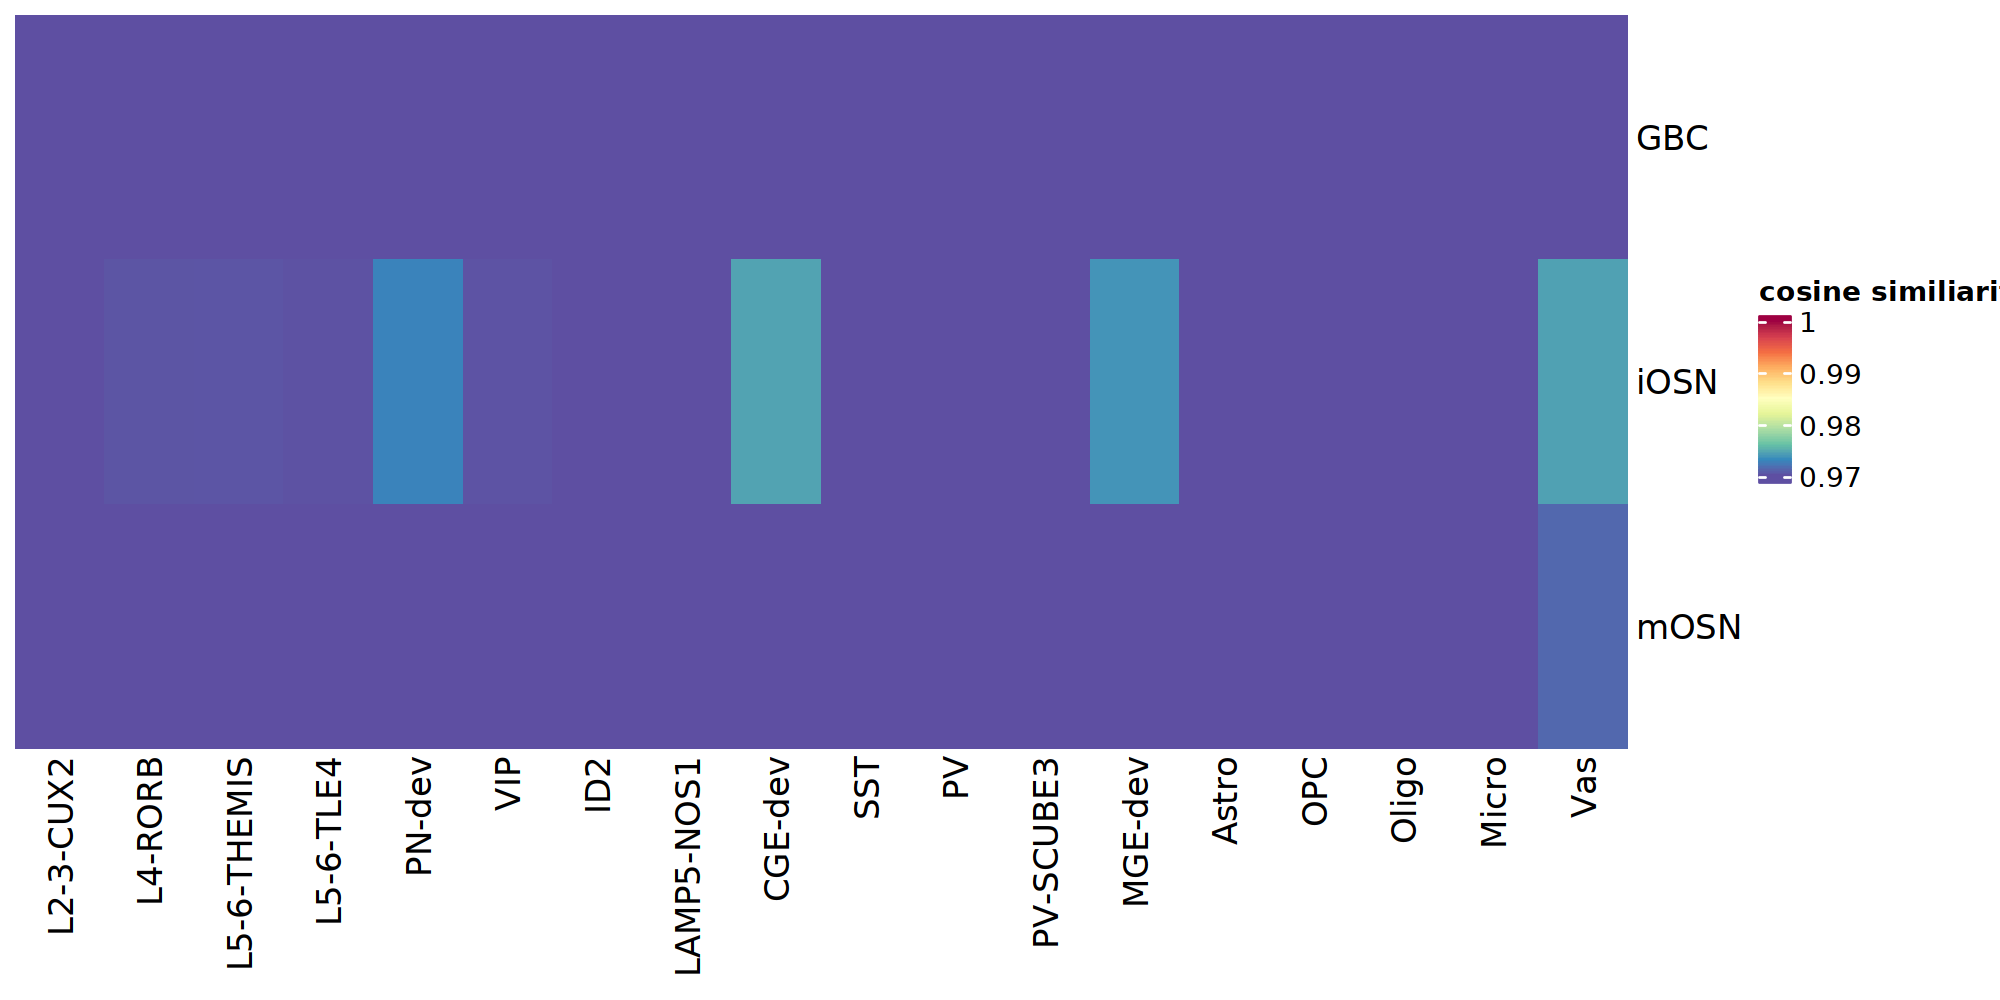

In [604]:
ComplexHeatmap::draw(Heatmap(
    cosine_sim[1:3,-1:-3], name = "cosine similiarity",
    col    = colorRamp2(seq(from=0.97,to=1,length=11),rev(brewer.pal(11, "Spectral"))),
    row_gap = unit(c(2.5), "mm"),
#             cell_fun = function(j, i, x, y, width, height, fill) {
#         if(cpr_df[i, j] > 0.5)
#             grid.text(sprintf("%.1f", cpr_df[i, j]), x, y, gp = gpar(fontsize = 3))
# },

    cluster_rows = FALSE,
    cluster_columns              = F,
    show_row_names               = T,
    show_column_names            = T,
    show_row_dend = F))

In [ ]:
devtools::install_github("GabrielHoffman/secoia", auth='LitingSong')

In [114]:
# # ent_N <- readRDS('/sc/arion/projects/CommonMind/roussp01a/ENT/snRNAseq/qc_scanpy/ent_nn_merge_cca.rds')
# # lister <- readH5AD('/sc/arion/projects/CommonMind/aging/hui/files/lister_processed.h5ad', use_hdf5=TRUE, verbose=F)
# meta.data_que <- ent_N@meta.data 
# meta.data_ref <- lister@colData 

# integ$major_clust <- meta.data_ref[rownames(integ),'major_clust']
# integ$stage_id <- meta.data_ref[rownames(integ),'stage_id']
# integ$dataset <- meta.data_que[gsub('_query','',rownames(integ)),'dataset']
# integ$cca_N_types_stage <- meta.data_que[gsub('_query','',rownames(integ)),'cca_N_types_stage']

# library(FNN)
# pred_major_clust <- knn(train = subset(integ, !grepl('query',rownames(integ)))[,1:2], 
#                     test =  subset(integ, grepl('query',rownames(integ)))[,1:2], cl = subset(integ, !grepl('query',rownames(integ)))$major_clust, k = 10)
# pred_stage <- knn(train = subset(integ, !grepl('query',rownames(integ)))[,1:2], 
#                     test =  subset(integ, grepl('query',rownames(integ)))[,1:2], cl = subset(integ, !grepl('query',rownames(integ)))$stage_id, k = 10)

# integ$pred_major_clust <- NA
# integ$pred_stage <- NA

# integ[grepl('_query',rownames(integ)),'pred_major_clust'] <- as.character(pred_major_clust)
# integ[grepl('_query',rownames(integ)),'pred_stage'] <- as.character(pred_stage)


# ggplot(integ,aes(V1, V2, color=dataset ))+geom_scattermore(pointsize=4)+theme_bw()+theme(aspect.ratio = 1)
# ggplot(integ,aes(V1, V2, color=cca_N_types_stage ))+geom_scattermore(pointsize=4)+theme_bw()+theme(aspect.ratio = 1)#+facet_wrap(~dataset)
# ggplot(integ,aes(V1, V2, color=pred_major_clust ))+geom_scattermore(pointsize=4)+theme_bw()+theme(aspect.ratio = 1)
# ggplot(integ,aes(V1, V2, color=pred_stage ))+geom_scattermore(pointsize=4)+theme_bw()+theme(aspect.ratio = 1)


[1] "ENT GBC"    "ENT e_iOSN" "ENT l_iOSN" "ENT mOSN"

[1] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
 [11] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
 [21] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
 [31] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
 [41] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
 [51] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
 [61] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
 [71] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
 [81] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
 [91] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[101] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[111] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[121] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[131] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[141] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[151] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[161] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[171] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[181] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[191] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[201] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[211] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[221] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[231] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[241] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[251] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[261] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[271] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[281] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[291] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[301] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[311] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[321] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT "
[331] "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "ENT " "NN "  "NN " 
[341] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[351] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[361] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[371] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[381] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[391] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[401] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[411] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[421] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[431] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[441] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[451] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[461] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[471] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[481] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[491] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[501] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[511] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "NN " 
[521] "NN "  "NN "  "NN "  "NN "  "NN "  "NN "  "N